In [2]:
from pathlib import Path
import pymupdf

In [3]:
pdf_path = Path("../data/raw")
list(pdf_path.glob("*.pdf"))

[WindowsPath('../data/raw/microsoft_report.pdf'),
 WindowsPath('../data/raw/Plan_stratégique_Impact.pdf'),
 WindowsPath('../data/raw/test.pdf'),
 WindowsPath('../data/raw/worldbank_report.pdf')]

In [4]:
#pdf_path = next(pdf_path.glob("*test*"))
pdf_path = next(pdf_path.glob("*Plan*"))

In [5]:
doc = pymupdf.open(pdf_path)

In [6]:
# Création d'identifiant
document_id = pdf_path.stem

In [7]:
document_id

'Plan_stratégique_Impact'

In [8]:
print(len(doc))
print(doc.metadata)

83
{'format': 'PDF 1.7', 'title': '', 'author': '', 'subject': '', 'keywords': '', 'creator': '', 'producer': '', 'creationDate': "D:20260923073518-07'00'", 'modDate': "D:20260923073518-07'00'", 'trapped': '', 'encryption': None}


In [9]:
pages_document = []

for page_index, page in enumerate(doc):
    page_structure = {
        "document_id": document_id,
        "page": page_index + 1,
        "width": page.rect.width,
        "height": page.rect.height,
        "elements": [] # dimensions de la page (surlignage en front)
    }

    pages_document.append(page_structure)

In [10]:
print(len(pages_document))

for page_structure in pages_document:
    print(page_structure)

83
{'document_id': 'Plan_stratégique_Impact', 'page': 1, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 2, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 3, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 4, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 5, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 6, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 7, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 8, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 9, 'width': 957.75, 'height': 539.25, 'elements': []}
{'document_id': 'Plan_stratégique_Impact', 'page': 1

## Extract tables element

In [11]:
for page_index, page in enumerate(doc):
    resultats_tableaux = page.find_tables()

    print(f"Page {page_index + 1} :",len(resultats_tableaux.tables),"tableau(x) détecté(s)")

    for tableau_index, tableau in enumerate(resultats_tableaux.tables):
        print(f"Tableau {tableau_index} :", tableau.row_count, "lignes", tableau.col_count, "colonnes")

        print("Bbox :", list(tableau.bbox))

Consider using the pymupdf_layout package for a greatly improved page layout analysis.
Page 1 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Page 2 : 2 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Tableau 1 : 2 lignes 2 colonnes
Bbox : [63.54899978637695, 333.989990234375, 368.1000061035156, 515.5910034179688]
Page 3 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Page 4 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Page 5 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Page 6 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colonnes
Bbox : [0.0, 0.00079345703125, 957.75, 539.1408081054688]
Page 7 : 1 tableau(x) détecté(s)
Tableau 0 : 1 lignes 2 colo

## Add tables to pages

In [12]:
for page_index, page in enumerate(doc):
    table_result = page.find_tables()

    for table_index, table in enumerate(table_result.tables):

        data_table = table.extract()

        if not data_table:
            continue
        
        columns = data_table[0]
        rows = data_table[1:]

        # Une table doit avoir au moins 2 colonnes
        if len(columns) < 2:
            continue

        # Une table doit avoir au moins une ligne de données
        if len(rows) < 1:
            continue

        table_element = {
            "type": "table",
            "table_index": table_index,
            "bbox": list(table.bbox),
            "columns": columns,
            "rows": rows
        }

        pages_document[page_index]["elements"].append(table_element)

In [13]:
pages_document

[{'document_id': 'Plan_stratégique_Impact',
  'page': 1,
  'width': 957.75,
  'height': 539.25,
  'elements': []},
 {'document_id': 'Plan_stratégique_Impact',
  'page': 2,
  'width': 957.75,
  'height': 539.25,
  'elements': [{'type': 'table',
    'table_index': 1,
    'bbox': [63.54899978637695,
     333.989990234375,
     368.1000061035156,
     515.5910034179688],
    'columns': ['Rédaction\nMaëliss DELACROIX\nDirectrice Impact\nDavidson Paris',
     'Approbation\nBertrand BAILLY\nDirecteur Général\nDavidson consulting'],
    'rows': [['Signature', 'Signature']]}]},
 {'document_id': 'Plan_stratégique_Impact',
  'page': 3,
  'width': 957.75,
  'height': 539.25,
  'elements': []},
 {'document_id': 'Plan_stratégique_Impact',
  'page': 4,
  'width': 957.75,
  'height': 539.25,
  'elements': []},
 {'document_id': 'Plan_stratégique_Impact',
  'page': 5,
  'width': 957.75,
  'height': 539.25,
  'elements': []},
 {'document_id': 'Plan_stratégique_Impact',
  'page': 6,
  'width': 957.75,
  '

## Extract text element

In [14]:
for page_index, page in enumerate(doc):
    text_blocks = page.get_text("blocks", sort=True)

    table_elements = [element for element in pages_document[page_index]["elements"] if element["type"] == "table"]

    for block in text_blocks:
        print(block)

(49.25, 199.39659118652344, 571.6389770507812, 278.8187255859375, 'PLAN STRATÉGIQUE\n', 0, 0)
(52.54999923706055, 258.3247985839844, 267.7115173339844, 348.5950012207031, 'Impact\n', 1, 0)
(49.25, 487.8161926269531, 451.4963684082031, 501.3687438964844, 'Certifié B Corp depuis 2018, quatre fois n°1 du classement Great Place To Work en Europe\n', 2, 0)
(52.04999923706055, 38.7982063293457, 374.78753662109375, 63.16875457763672, 'PÉRIMÈTRE & SUIVI DE MODIFICATIONS\n', 4, 0)
(52.04999923706055, 124.16020202636719, 313.22613525390625, 141.31875610351562, 'Ce plan stratégique est un document groupe. \n', 0, 0)
(52.04999923706055, 169.96018981933594, 485.53887939453125, 237.43875122070312, 'Il a été validé par l’ensemble des associé(e)s des différentes filiales en juillet \n2026.\nElles sont au nombre de 32 et sont réparties sur 21 sites, que vous pouvez \nretrouver ici ainsi que sur la carte ci-après. \n', 1, 0)
(52.04999923706055, 266.0901794433594, 472.00616455078125, 299.7687683105469, '

In [15]:
# Suppression des lignes consécutives strictement identiques.
def remove_consecutive_duplicate_lines(text):

    lines = text.splitlines()

    cleaned_lines = []

    for line in lines:

        line = line.strip()

        if not line:
            continue

        if (
            cleaned_lines
            and line == cleaned_lines[-1]
        ):
            continue

        cleaned_lines.append(line)

    return "\n".join(cleaned_lines)

In [16]:
for page_index, page in enumerate(doc):
    text_blocks = page.get_text("blocks", sort=True)

    table_elements = [element for element in pages_document[page_index]["elements"] if element["type"] == "table"]

    for block in text_blocks:
        [x0,y0,x1,y1,text,block_number,block_type] = block

        if block_type != 0:
            continue

        text = text.strip()

        text = remove_consecutive_duplicate_lines(
            text
        )

        if not text:
            continue

        text_bbox = [x0,y0,x1,y1]

        text_rectangle = pymupdf.Rect(text_bbox)

        inside_table = False

        for table_element in table_elements:
            table_rectangle = pymupdf.Rect(table_element["bbox"])

            # Vérification de la présence d'une intersection entre les deux rectangles
            if table_rectangle.intersects(text_rectangle):
                inside_table = True
                break

        if inside_table:
            continue

        text_element = {
            "type": 'text',
            "block_number": block_number,
            "bbox": text_bbox,
            "content": text
        }

        pages_document[page_index]["elements"].append(text_element)

In [17]:
element_types = {
    element["type"]
    for page_data in pages_document
    for element in page_data["elements"]
}

print(element_types)

{'table', 'text'}


In [18]:
for page in pages_document:
    print("Page:", page["page"])

    for element in page["elements"]:
        print(element["type"], "|", element["bbox"])

        if element["type"] == "text":
            print(repr(element["content"]))

Page: 1
text | [49.25, 199.39659118652344, 571.6389770507812, 278.8187255859375]
'PLAN STRATÉGIQUE'
text | [52.54999923706055, 258.3247985839844, 267.7115173339844, 348.5950012207031]
'Impact'
text | [49.25, 487.8161926269531, 451.4963684082031, 501.3687438964844]
'Certifié B Corp depuis 2018, quatre fois n°1 du classement Great Place To Work en Europe'
Page: 2
table | [63.54899978637695, 333.989990234375, 368.1000061035156, 515.5910034179688]
text | [52.04999923706055, 38.7982063293457, 374.78753662109375, 63.16875457763672]
'PÉRIMÈTRE & SUIVI DE MODIFICATIONS'
text | [52.04999923706055, 124.16020202636719, 313.22613525390625, 141.31875610351562]
'Ce plan stratégique est un document groupe.'
text | [52.04999923706055, 169.96018981933594, 485.53887939453125, 237.43875122070312]
'Il a été validé par l’ensemble des associé(e)s des différentes filiales en juillet\n2026.\nElles sont au nombre de 32 et sont réparties sur 21 sites, que vous pouvez\nretrouver ici ainsi que sur la carte ci-apr

## Extract images

In [19]:
for page_index, page in enumerate(doc):
    page_images = page.get_images(full=True)

    for image_index, image_info in enumerate(page_images):
        xref = image_info[0] # identifiant interne
        width = image_info[2]
        height = image_info[3]

        image_positions = page.get_image_rects(xref) # récupération des positions de l'image sur la page

        for occurrence_index, position in enumerate(image_positions):
            image_id = (f"{document_id}_page_{page_index + 1}_image_{image_index}_occurrence_{occurrence_index}") # occurrence: combien de fois une même image est affiché sur la page

            image_element = {
                "type": "image",
                "image_id": image_id,
                "image_index": image_index,
                "xref": xref,
                "width": width,
                "height": height,
                "bbox": list(position)
            }

            pages_document[page_index]["elements"].append(image_element)

In [20]:
for page in pages_document:
    print("\nPage:", page["page"])

    for element in page["elements"]:
        print(element["type"], "|", element["bbox"])

        if element["type"] == "image":
            print("ID:",element["image_id"])

            print("Size", element["width"],"x", element["height"])


Page: 1
text | [49.25, 199.39659118652344, 571.6389770507812, 278.8187255859375]
text | [52.54999923706055, 258.3247985839844, 267.7115173339844, 348.5950012207031]
text | [49.25, 487.8161926269531, 451.4963684082031, 501.3687438964844]
image | [920.25, 25.489990234375, 940.5, 44.989990234375]
ID: Plan_stratégique_Impact_page_1_image_0_occurrence_0
Size 27 x 26
image | [0.0, 0.000732421875, 957.75, 538.3907470703125]
ID: Plan_stratégique_Impact_page_1_image_1_occurrence_0
Size 2100 x 1181
image | [48.0, 40.49498748779297, 196.5, 67.489990234375]
ID: Plan_stratégique_Impact_page_1_image_2_occurrence_0
Size 412 x 74

Page: 2
table | [63.54899978637695, 333.989990234375, 368.1000061035156, 515.5910034179688]
text | [52.04999923706055, 38.7982063293457, 374.78753662109375, 63.16875457763672]
text | [52.04999923706055, 124.16020202636719, 313.22613525390625, 141.31875610351562]
text | [52.04999923706055, 169.96018981933594, 485.53887939453125, 237.43875122070312]
text | [52.04999923706055,

### Nombre d'images extraites

In [21]:
image_count = 0

for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] == "image":
            image_count += 1

print("Nombre total d'images extraites :", image_count)

Nombre total d'images extraites : 166


### Recording each images

image_id : occurence visible sur la page

asset_id : fichier image stocké

storage_path = emplacement du fichier

In [22]:
# Création banque d'images

image_bank_root = Path("image_bank")

image_bank_root.mkdir(exist_ok=True)

image_bank = []
saved_assets = set() # évite d’enregistrer plusieurs fois la même image si elle possède plusieurs occurrences

In [23]:
for page_index, page in enumerate(pages_document):
    page_number = page["page"]

    page_folder = image_bank_root/document_id/f"page_{page_number}"

    page_folder.mkdir(parents=True,exist_ok=True)

    for element in page["elements"]:
        if element["type"] != "image":
            continue

        asset_id = f"{document_id}_page_{page_number}_image_{element['image_index']}"

        element["asset_id"] = asset_id

        if asset_id in saved_assets:
            continue

        extracted_image = doc.extract_image(element["xref"])

        extension = extracted_image["ext"]

        file_name = f"image_{element['image_index']}.{extension}"

        file_path = page_folder/file_name

        file_path.write_bytes(extracted_image["image"])

        storage_path = file_path.as_posix() # pour stocker par exemple : image_bank/test/page_2/image_0.jpeg, plus portable pour une application

        element["storage_path"] = storage_path

        image_record = {
            "asset_id": asset_id,
            "document_id": document_id,
            "page": page_number,
            "image_index": element["image_index"],
            "xref": element["xref"],
            "width": element["width"],
            "height": element["height"],
            "extension": extension,
            "storage_path": storage_path
        }

        image_bank.append(image_record)

        saved_assets.add(asset_id)

In [24]:
print("Number of stored images:", len(image_bank))

for image_record in image_bank:
    print(image_record)

Number of stored images: 165
{'asset_id': 'Plan_stratégique_Impact_page_1_image_0', 'document_id': 'Plan_stratégique_Impact', 'page': 1, 'image_index': 0, 'xref': 14, 'width': 27, 'height': 26, 'extension': 'png', 'storage_path': 'image_bank/Plan_stratégique_Impact/page_1/image_0.png'}
{'asset_id': 'Plan_stratégique_Impact_page_1_image_1', 'document_id': 'Plan_stratégique_Impact', 'page': 1, 'image_index': 1, 'xref': 17, 'width': 2100, 'height': 1181, 'extension': 'png', 'storage_path': 'image_bank/Plan_stratégique_Impact/page_1/image_1.png'}
{'asset_id': 'Plan_stratégique_Impact_page_1_image_2', 'document_id': 'Plan_stratégique_Impact', 'page': 1, 'image_index': 2, 'xref': 19, 'width': 412, 'height': 74, 'extension': 'png', 'storage_path': 'image_bank/Plan_stratégique_Impact/page_1/image_2.png'}
{'asset_id': 'Plan_stratégique_Impact_page_2_image_0', 'document_id': 'Plan_stratégique_Impact', 'page': 2, 'image_index': 0, 'xref': 14, 'width': 27, 'height': 26, 'extension': 'png', 'storag

In [25]:
for element in pages_document:
    print(element)

{'document_id': 'Plan_stratégique_Impact', 'page': 1, 'width': 957.75, 'height': 539.25, 'elements': [{'type': 'text', 'block_number': 0, 'bbox': [49.25, 199.39659118652344, 571.6389770507812, 278.8187255859375], 'content': 'PLAN STRATÉGIQUE'}, {'type': 'text', 'block_number': 1, 'bbox': [52.54999923706055, 258.3247985839844, 267.7115173339844, 348.5950012207031], 'content': 'Impact'}, {'type': 'text', 'block_number': 2, 'bbox': [49.25, 487.8161926269531, 451.4963684082031, 501.3687438964844], 'content': 'Certifié B Corp depuis 2018, quatre fois n°1 du classement Great Place To Work en Europe'}, {'type': 'image', 'image_id': 'Plan_stratégique_Impact_page_1_image_0_occurrence_0', 'image_index': 0, 'xref': 14, 'width': 27, 'height': 26, 'bbox': [920.25, 25.489990234375, 940.5, 44.989990234375], 'asset_id': 'Plan_stratégique_Impact_page_1_image_0', 'storage_path': 'image_bank/Plan_stratégique_Impact/page_1/image_0.png'}, {'type': 'image', 'image_id': 'Plan_stratégique_Impact_page_1_image_

In [26]:
for element in pages_document:
    print(element.keys())

dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(['document_id', 'page', 'width', 'height', 'elements'])
dict_keys(

In [27]:
for page in pages_document:
    for element in page["elements"]:
        if element["type"] == "image":
            print(element["image_id"],"->",element["asset_id"],"->",element.get("storage_path"))

Plan_stratégique_Impact_page_1_image_0_occurrence_0 -> Plan_stratégique_Impact_page_1_image_0 -> image_bank/Plan_stratégique_Impact/page_1/image_0.png
Plan_stratégique_Impact_page_1_image_1_occurrence_0 -> Plan_stratégique_Impact_page_1_image_1 -> image_bank/Plan_stratégique_Impact/page_1/image_1.png
Plan_stratégique_Impact_page_1_image_2_occurrence_0 -> Plan_stratégique_Impact_page_1_image_2 -> image_bank/Plan_stratégique_Impact/page_1/image_2.png
Plan_stratégique_Impact_page_2_image_0_occurrence_0 -> Plan_stratégique_Impact_page_2_image_0 -> image_bank/Plan_stratégique_Impact/page_2/image_0.png
Plan_stratégique_Impact_page_2_image_1_occurrence_0 -> Plan_stratégique_Impact_page_2_image_1 -> image_bank/Plan_stratégique_Impact/page_2/image_1.jpeg
Plan_stratégique_Impact_page_2_image_2_occurrence_0 -> Plan_stratégique_Impact_page_2_image_2 -> image_bank/Plan_stratégique_Impact/page_2/image_2.png
Plan_stratégique_Impact_page_2_image_3_occurrence_0 -> Plan_stratégique_Impact_page_2_image_3

Le tableau a été ajouté avant le texte car l'extraction a été faite en premier. On doit donc mettre la liste dans l'ordre.

### Triage selon ordre d'apparition

In [28]:
for page in pages_document:
    page["elements"] = sorted(
        page["elements"],
        key=lambda element: (
            element["bbox"][1], # triage avec y0
            element["bbox"][0]  # et si plusieurs y0 sont égaux, triage avec x0
        )
    )

In [29]:
for page_data in pages_document:
    print(
        "\nPage:",
        page_data["page"]
    )

    for element in page_data["elements"]:
        print(
            element["type"],
            "| y0:",
            round(element["bbox"][1], 2),
            "| x0:",
            round(element["bbox"][0], 2)
        )


Page: 1
image | y0: 0.0 | x0: 0.0
image | y0: 25.49 | x0: 920.25
image | y0: 40.49 | x0: 48.0
text | y0: 199.4 | x0: 49.25
text | y0: 258.32 | x0: 52.55
text | y0: 487.82 | x0: 49.25

Page: 2
image | y0: 25.49 | x0: 920.25
text | y0: 38.8 | x0: 52.05
image | y0: 71.98 | x0: 516.75
text | y0: 124.16 | x0: 52.05
text | y0: 169.96 | x0: 52.05
text | y0: 266.09 | x0: 52.05
table | y0: 333.99 | x0: 63.55
image | y0: 471.65 | x0: 103.5
image | y0: 480.65 | x0: 259.5
text | y0: 502.09 | x0: 928.35

Page: 3
text | y0: 22.88 | x0: 49.25
image | y0: 25.49 | x0: 920.25
text | y0: 39.31 | x0: 622.7
text | y0: 53.58 | x0: 680.1
text | y0: 96.25 | x0: 277.23
text | y0: 110.03 | x0: 49.25
text | y0: 110.03 | x0: 277.23
text | y0: 110.03 | x0: 486.78
text | y0: 110.03 | x0: 696.33
text | y0: 116.67 | x0: 233.9
text | y0: 116.67 | x0: 645.55
text | y0: 116.67 | x0: 855.2
text | y0: 137.06 | x0: 269.48
text | y0: 152.09 | x0: 42.03
text | y0: 152.09 | x0: 479.63
text | y0: 152.09 | x0: 689.05
text | y0

# Classification des images

In [30]:
for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        storage_path = element.get("storage_path") # .get() : évite KeyError si la clé n'existe pas, retourne None

        print(
            "Page :", page_data["page"],
            "| Image ID :", element["image_id"],
            "| Path :", storage_path
        )

Page : 1 | Image ID : Plan_stratégique_Impact_page_1_image_1_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_1/image_1.png
Page : 1 | Image ID : Plan_stratégique_Impact_page_1_image_0_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_1/image_0.png
Page : 1 | Image ID : Plan_stratégique_Impact_page_1_image_2_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_1/image_2.png
Page : 2 | Image ID : Plan_stratégique_Impact_page_2_image_0_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_2/image_0.png
Page : 2 | Image ID : Plan_stratégique_Impact_page_2_image_3_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_2/image_3.jpeg
Page : 2 | Image ID : Plan_stratégique_Impact_page_2_image_2_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_2/image_2.png
Page : 2 | Image ID : Plan_stratégique_Impact_page_2_image_1_occurrence_0 | Path : image_bank/Plan_stratégique_Impact/page_2/image_1.jpeg
Page : 3 | Image ID : Plan_stratégique_

## CLIP

In [31]:
from transformers import pipeline

c:\Users\nico_\Desktop\rag_pdf\venvrag\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
import time

clip_loading_start = time.perf_counter()

image_classifier = pipeline(
    task="zero-shot-image-classification",
    model="openai/clip-vit-base-patch32",
    device=-1
)

clip_loading_duration = (time.perf_counter() - clip_loading_start)

print("CLIP loading time :",round(clip_loading_duration, 2),"seconds")

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 23126.08it/s]


CLIP loading time : 2.28 seconds


In [33]:
# Définition des catégories
candidate_labels = [
    "a chart or graph showing numerical data",
    "a diagram or schematic",
    "an infographic",
    "a map",
    "a logo or decorative graphic",
    "a scanned document",
    "a photograph"
]

DEPLOT_LABELS = {
    "a chart or graph showing numerical data",
    "an infographic"
}

DEPLOT_MIN_SCORE = 0.50

In [34]:
# Test
first_image_path = image_bank[0]["storage_path"]
print(first_image_path)

image_bank/Plan_stratégique_Impact/page_1/image_0.png


In [35]:
# Classification
classification_results = image_classifier(first_image_path,candidate_labels=candidate_labels)

for result in classification_results:
    print(result["label"],":",round(result["score"],3))

a logo or decorative graphic : 0.934
a scanned document : 0.034
a diagram or schematic : 0.015
an infographic : 0.008
a chart or graph showing numerical data : 0.007
a map : 0.003
a photograph : 0.0


In [36]:
best_result = classification_results[0]
print(best_result["label"])
print("Confiance:", round(best_result["score"],3))

a logo or decorative graphic
Confiance: 0.934


In [37]:
# correspondance asset -> chemin

asset_paths = {
    image_record["asset_id"]:
    image_record["storage_path"]

    for image_record in image_bank
}

In [38]:
# Classification CLIP de toutes les images

clip_start = time.perf_counter()

clip_calls = 0
clip_inference_duration = 0.0


# Classification des images

for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue


        # Réparation du chemin si storage_path manque

        if "storage_path" not in element:

            asset_id = element["asset_id"]

            if asset_id in asset_paths:

                element["storage_path"] = asset_paths[asset_id]

                print(
                    "Path restored:",
                    element["image_id"],
                    "->",
                    element["storage_path"]
                )

            else:

                print(
                    "No file found for:",
                    element["image_id"]
                )

                # Impossible de classifier sans fichier
                continue


        # Inférence CLIP

        image_start = time.perf_counter()

        classification_results = image_classifier(
            element["storage_path"],
            candidate_labels=candidate_labels
        )

        image_duration = (
            time.perf_counter() - image_start
        )

        clip_inference_duration += image_duration
        clip_calls += 1


        # Catégorie principale CLIP

        best_result = classification_results[0]

        element["image_category"] = best_result["label"]

        element["classification_score"] = float(
            best_result["score"]
        )


        # Conservation de tous les résultats CLIP

        element["classification_results"] = [
            {
                "label": result["label"],
                "score": float(result["score"])
            }
            for result in classification_results
        ]



        # Meilleur résultat parmi les catégories pouvant être envoyées à DePlot 
        # - chart / graph
        # - infographic

        deplot_results = [
            result
            for result in classification_results
            if result["label"] in DEPLOT_LABELS
        ]

        best_deplot_result = max(
            deplot_results,
            key=lambda x: x["score"]
        )

        deplot_score = float(
            best_deplot_result["score"]
        )

        element["deplot_candidate_type"] = (
            best_deplot_result["label"]
        )

        element["deplot_score"] = deplot_score


        # Meilleur résultat NON candidat DePlot

        non_deplot_results = [
            result
            for result in classification_results
            if result["label"] not in DEPLOT_LABELS
        ]

        best_non_deplot_result = max(
            non_deplot_results,
            key=lambda x: x["score"]
        )

        non_deplot_score = float(
            best_non_deplot_result["score"]
        )

        element["non_deplot_type"] = (
            best_non_deplot_result["label"]
        )

        element["non_deplot_score"] = (
            non_deplot_score
        )


        # Décision pour DePlot
        # Si la catégorie principale CLIP est :
        # - chart      -> graphique
        # - infographic -> graphique possible
        # - autre      -> pas de DePlot
        

        if (
            best_result["label"]
            == "a chart or graph showing numerical data"
            and element["classification_score"] >= DEPLOT_MIN_SCORE
        ):

            chart_decision = "chart"
            is_chart = True

        elif (
            best_result["label"]
            == "an infographic"
            and element["classification_score"] >= DEPLOT_MIN_SCORE
        ):

            chart_decision = "possible_chart"
            is_chart = True

        else:

            chart_decision = "not_chart"
            is_chart = False


        element["chart_decision"] = (
            chart_decision
        )

        element["is_chart"] = (
            is_chart
        )


        
        # Enregistrement de la latence CLIP pour cette image
        
        element["clip_inference_time"] = (
            image_duration
        )


        # Affichage résultat image
      

        print(
            element["image_id"],
            "| Category:",
            element["image_category"],
            "| Category score:",
            round(
                element["classification_score"],
                3
            ),
            "| DePlot candidate:",
            element["deplot_candidate_type"],
            "| DePlot score:",
            round(
                deplot_score,
                3
            ),
            "| Best non-DePlot:",
            element["non_deplot_type"],
            round(
                non_deplot_score,
                3
            ),
            "| Decision:",
            chart_decision,
            "| DePlot:",
            is_chart,
            "| CLIP latency:",
            round(
                image_duration,
                3
            ),
            "seconds"
        )


# ============================================================
# Statistiques globales CLIP
# ============================================================

clip_total_duration = (
    time.perf_counter() - clip_start
)


print("\n==============================")
print("CLIP statistics")
print("==============================")


print(
    "Number of calls:",
    clip_calls
)


print(
    "Inference time:",
    round(
        clip_inference_duration,
        2
    ),
    "seconds"
)


print(
    "Total processing time:",
    round(
        clip_total_duration,
        2
    ),
    "seconds"
)


if clip_calls > 0:

    print(
        "Average inference time per image:",
        round(
            clip_inference_duration / clip_calls,
            3
        ),
        "seconds"
    )

    print(
        "Average total time per image:",
        round(
            clip_total_duration / clip_calls,
            3
        ),
        "seconds"
    )

Plan_stratégique_Impact_page_1_image_1_occurrence_0 | Category: a logo or decorative graphic | Category score: 0.684 | DePlot candidate: an infographic | DePlot score: 0.103 | Best non-DePlot: a logo or decorative graphic 0.684 | Decision: not_chart | DePlot: False | CLIP latency: 0.103 seconds
Plan_stratégique_Impact_page_1_image_0_occurrence_0 | Category: a logo or decorative graphic | Category score: 0.934 | DePlot candidate: an infographic | DePlot score: 0.008 | Best non-DePlot: a logo or decorative graphic 0.934 | Decision: not_chart | DePlot: False | CLIP latency: 0.08 seconds
Plan_stratégique_Impact_page_1_image_2_occurrence_0 | Category: a logo or decorative graphic | Category score: 0.933 | DePlot candidate: an infographic | DePlot score: 0.017 | Best non-DePlot: a logo or decorative graphic 0.933 | Decision: not_chart | DePlot: False | CLIP latency: 0.087 seconds
Plan_stratégique_Impact_page_2_image_0_occurrence_0 | Category: a logo or decorative graphic | Category score: 0.

### Selection des graphiques pour Deplot

In [39]:
deplot_candidates = []


for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue


        # Vérifie que CLIP a bien analysé l'image
        if "is_chart" not in element:
            continue


        # Sélection des images à envoyer à DePlot :
        #
        # - chart
        # - possible_chart (infographic)
        #
        # is_chart == True dans les deux cas
        if not element["is_chart"]:
            continue


        # Vérification du chemin de l'image
        if "storage_path" not in element:
            continue


        # Ajout aux candidats DePlot
        deplot_candidates.append(element)



# Affichage des candidats DePlot

print("\n==============================")
print("DePlot candidates")
print("==============================")


print(
    "Number of candidates:",
    len(deplot_candidates)
)


for element in deplot_candidates:

    print(
        element["image_id"],
        "| Category:",
        element["image_category"],
        "| Category score:",
        round(
            element["classification_score"],
            3
        ),
        "| DePlot candidate:",
        element["deplot_candidate_type"],
        "| DePlot score:",
        round(
            element["deplot_score"],
            3
        ),
        "| Decision:",
        element["chart_decision"],
        "| Path:",
        element["storage_path"]
    )


DePlot candidates
Number of candidates: 15
Plan_stratégique_Impact_page_5_image_2_occurrence_0 | Category: an infographic | Category score: 0.788 | DePlot candidate: an infographic | DePlot score: 0.788 | Decision: possible_chart | Path: image_bank/Plan_stratégique_Impact/page_5/image_2.jpeg
Plan_stratégique_Impact_page_5_image_1_occurrence_0 | Category: an infographic | Category score: 0.889 | DePlot candidate: an infographic | DePlot score: 0.889 | Decision: possible_chart | Path: image_bank/Plan_stratégique_Impact/page_5/image_1.jpeg
Plan_stratégique_Impact_page_14_image_1_occurrence_0 | Category: a chart or graph showing numerical data | Category score: 0.903 | DePlot candidate: a chart or graph showing numerical data | DePlot score: 0.903 | Decision: chart | Path: image_bank/Plan_stratégique_Impact/page_14/image_1.png
Plan_stratégique_Impact_page_14_image_2_occurrence_0 | Category: a chart or graph showing numerical data | Category score: 0.752 | DePlot candidate: a chart or grap

### DePlot

In [40]:
from transformers import Pix2StructProcessor,Pix2StructForConditionalGeneration

In [41]:
# Modèle
deplot_model_name = "google/deplot"

deplot_loading_start = time.perf_counter()

# Processeur (prépare l'image et la consigne)
deplot_processor = Pix2StructProcessor.from_pretrained('google/deplot')

# Chargement du modèle
deplot_model =  Pix2StructForConditionalGeneration.from_pretrained(deplot_model_name)

# mode inférence, sans entraînement
deplot_model.eval()

deplot_loading_duration = (time.perf_counter() - deplot_loading_start)

print(
    "DePlot loading time :",
    round(deplot_loading_duration, 2),
    "seconds"
)

Loading weights: 100%|██████████| 285/285 [00:00<00:00, 314.95it/s]


DePlot loading time : 4.44 seconds


In [42]:
from PIL import Image
import torch
import time

### Plusieurs graphiques par page

asset_id est important parce que image_id représente une occurrence de l'image, alors que asset_id représente l'image elle-même Donc si le même asset apparaît 5 fois, Deplot est appelé une seule fois

In [43]:
# DePlot
# Analyse uniquement les images sélectionnées par CLIP


deplot_cache = {}

deplot_start = time.perf_counter()

deplot_calls = 0
deplot_cache_hits = 0
deplot_processing_duration = 0.0


# Parcours des pages

for page_data in pages_document:

    for element in page_data["elements"]:

        
        # Ignore tout ce qui n'est pas une image

        if element["type"] != "image":
            continue


        # Ignore les images non sélectionnées par CLIP
        #
        # is_chart == True pour :
        # - chart
        # - possible_chart / infographic

        if not element.get("is_chart", False):
            continue


        # Vérification du chemin

        if "storage_path" not in element:
            continue


        asset_id = element["asset_id"]


        # Cache
        # Si cette image a déjà été analysée par DePlot, on réutilise directement le résultat.

        if asset_id in deplot_cache:

            element["deplot_raw"] = (
                deplot_cache[asset_id]
            )

            element["deplot_from_cache"] = True

            deplot_cache_hits += 1

            continue


        # Nouvelle analyse DePlot

        print(
            "\nAnalyzing with DePlot:",
            element["image_id"],
            "| CLIP category:",
            element["image_category"],
            "| Decision:",
            element["chart_decision"]
        )


        chart_start = time.perf_counter()


        # Chargement de l'image

        try:

            with Image.open(
                element["storage_path"]
            ) as image:

                chart_image = image.convert("RGB")

        except Exception as e:

            print(
                "Error loading image:",
                element["image_id"],
                "|",
                e
            )

            continue


        # Préparation pour DePlot

        model_inputs = deplot_processor(
            images=chart_image,
            text="Generate underlying data table of the figure below:",
            return_tensors="pt"
        )


        # Inférence DePlot

        with torch.inference_mode():

            predictions = deplot_model.generate(
                **model_inputs,
                max_new_tokens=256
            )


        # Décodage

        raw_chart_table = deplot_processor.decode(
            predictions[0],
            skip_special_tokens=True
        )


        # Temps de traitement

        chart_duration = (
            time.perf_counter() - chart_start
        )


        # Mise en cache

        deplot_cache[asset_id] = (
            raw_chart_table
        )


        # Enregistrement dans l'élément

        element["deplot_raw"] = (
            raw_chart_table
        )

        element["deplot_inference_time"] = (
            chart_duration
        )

        element["deplot_from_cache"] = False


        # Statistiques

        deplot_processing_duration += (
            chart_duration
        )

        deplot_calls += 1


        # Affichage

        print(
            element["image_id"],
            "| DePlot time:",
            round(
                chart_duration,
                2
            ),
            "seconds"
        )

        print(
            "DePlot result:"
        )

        print(
            raw_chart_table
        )

# Statistiques globales DePlot

deplot_total_duration = (
    time.perf_counter() - deplot_start
)


print("\n==============================")
print("DePlot statistics")
print("==============================")


print(
    "Unique model calls:",
    deplot_calls
)


print(
    "Cache hits:",
    deplot_cache_hits
)


print(
    "Processing time:",
    round(
        deplot_processing_duration,
        2
    ),
    "seconds"
)


print(
    "Total loop time:",
    round(
        deplot_total_duration,
        2
    ),
    "seconds"
)


if deplot_calls > 0:

    print(
        "Average time per model call:",
        round(
            deplot_processing_duration / deplot_calls,
            2
        ),
        "seconds"
    )


Analyzing with DePlot: Plan_stratégique_Impact_page_5_image_2_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_5_image_2_occurrence_0 | DePlot time: 109.07 seconds
DePlot result:
TITLE | Davidson vue du ciel<0x0A>Implantations | Cibasoft<0x0A>2000<0x0A>Davidson ie.net<0x0A>3000<0x0A>Davies<0x0A>3000<0x0A>L<0x0A>Metre<0x0A>Djijon<0x0A>Strabourg<0x0A>B<0x0A>M<0x0A>Metre<0x0A>Dijon<0x0A>Strabourg<0x0A>B<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>M<0x0A>

Analyzing with DePlot: Plan_stratégique_I

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_5_image_1_occurrence_0 | DePlot time: 29.19 seconds
DePlot result:
TITLE |  <0x0A> Redirection<0x0A>Redirection | 0.9% <0x0A> Une offre<0x0A>complète | 1.1% <0x0A> Une offre<0x0A>économie | 3.5% <0x0A> Networks | 9.8% <0x0A> Acceleration<0x0A>digitale | 1.7% <0x0A> Acceleration<0x0A>digitale | 0.9%

Analyzing with DePlot: Plan_stratégique_Impact_page_14_image_1_occurrence_0 | CLIP category: a chart or graph showing numerical data | Decision: chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_14_image_1_occurrence_0 | DePlot time: 72.74 seconds
DePlot result:
TITLE |  <0x0A>  | (C0 ; M2) | (C0 ; M3) | (C1 ; M2) | (C1 ; M3) | (C2 ; M0) | (C2 ; M2) | (C2 ; M3) <0x0A> 2022 | 17 | 8 | 2 | 14 | 11 | 14 | 0 <0x0A> 2023 | 22 | 15 | 1 | 13 | 13 | 13 | 0 <0x0A> 2024 | 29 | 17 | 1 | 10 | 9 | 9 | 6 <0x0A> 2025 | 27 | 4 | 0 | 0 | 36 | 36 | 2

Analyzing with DePlot: Plan_stratégique_Impact_page_14_image_2_occurrence_0 | CLIP category: a chart or graph showing numerical data | Decision: chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_14_image_2_occurrence_0 | DePlot time: 19.48 seconds
DePlot result:
TITLE |  <0x0A>  |  <0x0A> 2022 | 60 <0x0A> 2023 | 122 <0x0A> 2024 | 159 <0x0A> 2025 | 189

Analyzing with DePlot: Plan_stratégique_Impact_page_14_image_3_occurrence_0 | CLIP category: a chart or graph showing numerical data | Decision: chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_14_image_3_occurrence_0 | DePlot time: 28.38 seconds
DePlot result:
TITLE |  <0x0A>  | Delegate underlying data table of the figure below:<0x0A> 2022 | 9824 <0x0A> 2023 | 19215 <0x0A> 2024 | 25183 <0x0A> 2025 | 22769

Analyzing with DePlot: Plan_stratégique_Impact_page_15_image_1_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_15_image_1_occurrence_0 | DePlot time: 139.25 seconds
DePlot result:
TITLE | Cadrer un projet de transition avec nos experts formes<0x0A>Solutions<0x0A>pêtes a lutilisation | Parcours de sensibilisation<0x0A>évolu1f et personnalisable<0x0A>aux enjeux plantétaires et solutions sectorielles | THE L7I B10<0x0A>INTER | The Luttle Big | 3000 | 150<0x0A>Éconservacion, The Eurode<0x0A>(Econéraция, républicaine et informations et services) | 160 | 50 | 100<0x0A>Parcours de sensibilisation<0x0A>évolu1f et personnalisable<0x0A>aux enjeux plantétaires et solutions sectorielles | 180 | 50 | 100<0x0A>Parcours de l'économie<0x0A>(Princies, Comptabilité carbonne, ACV, Éco-conception<0x0A>(Princies, Comptabilité carbonne, ACV, Éco-conception<0x0A>numéracio) | 130 | 40 | 40<0x0A>L'

Analyzing with DePlot: Plan_stratégique_Impact_page_37_image_1_occurrence_1 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_37_image_1_occurrence_1 | DePlot time: 134.47 seconds
DePlot result:
TITLE |  <0x0A>  | COMM I PIT GONE SPRINGS<0x0A>ROUGH JUMP TO CHAMP <0x0A> COMM I FIGHTING<0x0A>AFT. AUCC<0x0A>IWC MAJORMINA | 8 <0x0A> COMM I MINICAMINA<0x0A>D5 MINI2 | 13 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI1 | 14 <0x0A> COMM I MINICAMINA<0x0A>IWC MINI | 12 <0x0A> COMM I MINICAMINA<0x0A>IWC MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>D9 MINI | 11 <0x0A> COMM I MINICAMINA<0x0A>

Analyzing with DePlot: Plan_stratégique_Impact_page_40_image_1_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_40_image_1_occurrence_0 | DePlot time: 29.71 seconds
DePlot result:
TITLE |  <0x0A>  | CH1907 SO MDG <0x0A> Michel Plasse<0x0A>Laura Pottinger<0x0A>Eric Greer<0x0A>Stephen Fry<0x0A>Stephan Happ<0x0A>竹田城<0xE8><0xB7><0xA1>号<0x0A>David Son<0x0A>Laura Torene<0x0A>Solidavi to<0x0A>Y.P. Jabal<0x0A>Eric St. Sebastian<0x0A>Sofia Tschan<0x0A>Davidson<0x0A>T.J. Barron<0x0A>Solidar | 87.7

Analyzing with DePlot: Plan_stratégique_Impact_page_44_image_1_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_44_image_1_occurrence_0 | DePlot time: 12.61 seconds
DePlot result:
TITLE |  <0x0A>  |  <0x0A> Scopes 1 & 2 | 371 <0x0A> Scope 3 | 1532 <0x0A> S3 Hors SBTi | 670

Analyzing with DePlot: Plan_stratégique_Impact_page_45_image_7_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_45_image_7_occurrence_0 | DePlot time: 101.44 seconds
DePlot result:
TITLE |  <0x0A>  | Scope 1 | Scope 2 | Trajectoire SBTi <0x0A> 2021 | 850 | 65 | 922 <0x0A> 2022 | 795 | 57 | 850 <0x0A> 2023 | 890 | 54 | 936 <0x0A> 2024 | 620 | 63 | 679 <0x0A> 2025 | 595 | 62 | 720 <0x0A> 2026 | 675 | 58 | 680 <0x0A> 2027 | 637 | 62 | 637 <0x0A> 2028 | 590 | 59 | 595 <0x0A> 2029 | 545 | 55 | 545 <0x0A> 2030 | 505 | 50 | 505 <0x0A> 2031 | 465 | 46 | 465 <0x0A> 

Analyzing with DePlot: Plan_stratégique_Impact_page_45_image_8_occurrence_0 | CLIP category: a chart or graph showing numerical data | Decision: chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_45_image_8_occurrence_0 | DePlot time: 104.07 seconds
DePlot result:
TITLE |  <0x0A>  | Scope 3 | Trajectoire S3/VA | Trajectoire SBTi <0x0A> 2021 | 8338 | 8277 | 8277 <0x0A> 2022 | 8277 | 8272 | 8272 <0x0A> 2023 | 7732 | 7556 | 7320 <0x0A> 2024 | 6476 | 6601 | 6846 <0x0A> 2025 | 7029 | 7264 | 6336 <0x0A> 2026 | 5933 | 5924 | 5936 <0x0A> 2027 | 5502 | 5465 | 5502 <0x0A> 2028 | 5000 | 5043 | 5043 <0x0A> 2029 | 4579 | 4600 | 4600 <0x0A> 

Analyzing with DePlot: Plan_stratégique_Impact_page_49_image_2_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_49_image_2_occurrence_0 | DePlot time: 36.6 seconds
DePlot result:
Entity | Values <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0 <0x0A> THE LITUTION | 42.0

Analyzing with DePlot: Plan_stratégique_Impact_page_63_image_1_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_63_image_1_occurrence_0 | DePlot time: 56.67 seconds
DePlot result:
TITLE |  <0x0A> Collaborations | RAG | Notre plateforme interne, de l'infrastructure au modèle | Coults | Coutts | Sécurité des données | Frugalité | Adoption <0x0A> 1 | 1 | 2 | 1 | 2 | 1 | 2 <0x0A> 2 | 2 | 2 | 1 | 2 | 2 | 2 <0x0A> Game Changers | 2 | 1 | 1 | 5 | 5 | 3 <0x0A> Indépendance aux modèles | 3 | 1 | 1 | 3 | 3 | 2 <0x0A> Adoption | 2 | 1 | 1 | 1 | 2 | 2

Analyzing with DePlot: Plan_stratégique_Impact_page_66_image_1_occurrence_0 | CLIP category: an infographic | Decision: possible_chart


[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Plan_stratégique_Impact_page_66_image_1_occurrence_0 | DePlot time: 100.33 seconds
DePlot result:
TITLE |  <0x0A>  | THE SHIT<0x0A>H1 | J | KIT | ENEROIE & CUMAT | DES RÉSEAUX SOBRES<0x0A>P000 DES USADES CONNECTIS<0x0A>RESILIENTS | THE SHIT<0x0A>H2 | DES RÉSEAUX SOBRES<0x0A>P000 DES USADES<0x0A>CONNECTIS<0x0A>RESILIENTS | THE SHIRT<0x0A>ENERGIE & CLIMAT | DES RÉSEAUX SOBRES<0x0A>P000 DES USADES<0x0A>CONNECTIS<0x0A>RESILIENTS | THE SHIRT<0x0A>ROY FICIT | THE SHIRT<0x0A>ENERGIE & CUMAT | QUELS MONDES<0x0A>V1 | DES RÉSEAUX SOBRES<0x0A>P0 | DES RÉSEAUX SOBRES<0x0A>P0 | DES RÉSEAUX SOBRES<0x0A>CONNECTIS<0x0A>RESILIENTS <0x0A> THE SHIRT<0x0A>H1 | 1 | 1 | 1 | 1 | 1 | 1 | 1 <0x0A> THE SHIRT<0x0A>

DePlot statistics
Unique model calls: 14
Cache hits: 1
Processing time: 974.03 seconds
Total loop time: 974.04 seconds
Average time per model call: 69.57 seconds


<0x0A> : pointe un retour à la ligne

### Remplacement de <0x0A> par retour à la ligne

In [44]:
for page_data in pages_document:

    for element in page_data["elements"]:

        # Ignore tout ce qui n'est pas une image
        if element["type"] != "image":
            continue


        # Ignore les images non sélectionnées pour DePlot
        if not element.get("is_chart", False):
            continue


        # Vérifie que DePlot a bien produit un résultat
        if "deplot_raw" not in element:
            continue


        # Remplacement du token DePlot <0x0A> par un vrai saut de ligne
        clean_chart_table = (
            element["deplot_raw"]
            .replace("<0x0A>", "\n")
        )


        # Enregistrement du résultat nettoyé
        element["deplot_clean"] = clean_chart_table

In [45]:
for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] == "image" and element.get("is_chart", False) and "deplot_clean" in element:
            print("\nChart :", element["image_id"])
            print("CLIP category:", element["image_category"])
            print("Decision:", element["chart_decision"])
            print(element["deplot_clean"])


Chart : Plan_stratégique_Impact_page_5_image_2_occurrence_0
CLIP category: an infographic
Decision: possible_chart
TITLE | Davidson vue du ciel
Implantations | Cibasoft
2000
Davidson ie.net
3000
Davies
3000
L
Metre
Djijon
Strabourg
B
M
Metre
Dijon
Strabourg
B
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M
M


Chart : Plan_stratégique_Impact_page_5_image_1_occurrence_0
CLIP category: an infographic
Decision: possible_chart
TITLE |  
 Redirection
Redirection | 0.9% 
 Une offre
complète | 1.1% 
 Une offre
économie | 3.5% 
 Networks | 9.8% 
 Acceleration
digitale | 1.7% 
 Acceleration
digitale | 0.9%

Chart : Plan_stratégique_Impact_page_14_image_1_occurrence_0
CLIP category: a chart or graph showing numerical data
Decision: chart
TITLE |  
  | (C0 ; M2) | (C0 ; M3) | (C1 ; M2) | (C1 ; M3) | (C2 ; M0) | (C2 ; M2) | (C2 ; M3) 
 2022 | 17 | 8 | 2 | 14 | 11 | 14 

# Validation Deplot

In [46]:
def is_number(value):
    try:
        float(
            value.strip()
            .replace("%", "")
            .replace(",", ".")
            .replace(" ", "")
        )
        return True
    except ValueError:
        return False

def validate_deplot_result(text):

    if not text:
        return False

    text = text.strip()

    if len(text) < 10:
        return False

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if len(lines) < 2:
        return False


    # ========================================================
    # Lignes tabulaires
    # ========================================================

    table_lines = [
        line
        for line in lines
        if "|" in line
    ]

    if len(table_lines) < 2:
        return False


    # ========================================================
    # Parsing
    # ========================================================

    parsed_rows = [
        [
            cell.strip()
            for cell in line.split("|")
        ]
        for line in table_lines
    ]


    # ========================================================
    # Nombre de colonnes dominant
    # ========================================================

    column_counts = [
        len(row)
        for row in parsed_rows
    ]

    dominant_column_count = max(
        set(column_counts),
        key=column_counts.count
    )

    if dominant_column_count < 2:
        return False


    # ========================================================
    # Lignes cohérentes
    # ========================================================

    consistent_rows = [
        row
        for row in parsed_rows
        if len(row) == dominant_column_count
    ]

    if len(consistent_rows) < 2:
        return False


    # ========================================================
    # Cohérence globale
    # ========================================================

    consistency_ratio = (
        len(consistent_rows) / len(lines)
    )

    if consistency_ratio < 0.5:
        return False


    # ========================================================
    # Présence de données numériques
    # ========================================================

    numeric_cells = sum(
        1
        for row in consistent_rows
        for cell in row
        if is_number(cell)
    )

    if numeric_cells < 2:
        return False


    return True

In [47]:
# Application de la validation
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        if "deplot_clean" not in element:
            continue

        element["deplot_valid"] = (
            validate_deplot_result(
                element["deplot_clean"]
            )
        )

In [48]:
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        if "deplot_clean" not in element:
            continue

        print(
            element["image_id"],
            "| CLIP:",
            element["image_category"],
            "| Decision:",
            element["chart_decision"],
            "| DePlot valid:",
            element.get("deplot_valid", False)
        )

Plan_stratégique_Impact_page_5_image_2_occurrence_0 | CLIP: an infographic | Decision: possible_chart | DePlot valid: False
Plan_stratégique_Impact_page_5_image_1_occurrence_0 | CLIP: an infographic | Decision: possible_chart | DePlot valid: True
Plan_stratégique_Impact_page_14_image_1_occurrence_0 | CLIP: a chart or graph showing numerical data | Decision: chart | DePlot valid: True
Plan_stratégique_Impact_page_14_image_2_occurrence_0 | CLIP: a chart or graph showing numerical data | Decision: chart | DePlot valid: True
Plan_stratégique_Impact_page_14_image_3_occurrence_0 | CLIP: a chart or graph showing numerical data | Decision: chart | DePlot valid: True
Plan_stratégique_Impact_page_15_image_1_occurrence_0 | CLIP: an infographic | Decision: possible_chart | DePlot valid: False
Plan_stratégique_Impact_page_37_image_1_occurrence_1 | CLIP: an infographic | Decision: possible_chart | DePlot valid: False
Plan_stratégique_Impact_page_37_image_1_occurrence_0 | CLIP: an infographic | Decis

### Sélection finale des résultats DePlot utilisables pour le RAG

In [49]:
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        element["use_deplot_for_rag"] = (
            element.get("deplot_valid", False)
        )

In [50]:
valid_deplot_count = sum(
    1
    for page_data in pages_document
    for element in page_data["elements"]
    if (
        element["type"] == "image"
        and element.get("deplot_valid", False) is True
    )
)

print(
    "Valid DePlot results for RAG:",
    valid_deplot_count
)

Valid DePlot results for RAG: 9


### Extraction titre, colonnes et lignes des graphiques

In [51]:
def parse_deplot_table(text):

    if not text:
        return None

    lines = [
        line.strip()
        for line in text.splitlines()
        if line.strip()
    ]

    if not lines:
        return None


    # 1. Extraction du titre

    title = None

    if lines[0].upper().startswith("TITLE"):

        title_parts = [
            part.strip()
            for part in lines[0].split("|")
        ]

        if len(title_parts) >= 2:
            extracted_title = " | ".join(
                title_parts[1:]
            ).strip()

            if extracted_title:
                title = extracted_title

        # On retire la ligne TITLE pour analyser le tableau
        lines = lines[1:]


    if not lines:
        return None


    # 2. Conservation uniquement des lignes tabulaires

    table_lines = [
        line
        for line in lines
        if "|" in line
    ]

    if len(table_lines) < 2:
        return None


    # 3. Transformation en cellules

    parsed_lines = [
        [
            cell.strip()
            for cell in line.split("|")
        ]
        for line in table_lines
    ]


    # 4. Nombre de colonnes dominant

    column_counts = [
        len(row)
        for row in parsed_lines
    ]

    dominant_column_count = max(
        set(column_counts),
        key=column_counts.count
    )


    # 5. Suppression des lignes incohérentes

    consistent_rows = [
        row
        for row in parsed_lines
        if len(row) == dominant_column_count
    ]

    if len(consistent_rows) < 2:
        return None


    # 6. Première ligne = noms des colonnes

    columns = consistent_rows[0]

    # 7. Lignes de données

    rows = consistent_rows[1:]


    return {
        "title": title,
        "columns": columns,
        "rows": rows
    }

In [52]:
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        if not element.get("deplot_valid", False):
            continue

        parsed_table = parse_deplot_table(
            element["deplot_clean"]
        )

        element["deplot_parsed"] = parsed_table

In [53]:
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        # ----------------------------------------------------
        # Supprimer l'ancien parsing
        # ----------------------------------------------------

        element.pop("deplot_parsed", None)


        # ----------------------------------------------------
        # Pas de sortie DePlot
        # ----------------------------------------------------

        if "deplot_clean" not in element:
            continue


        # ----------------------------------------------------
        # Recalcul de la validation
        # ----------------------------------------------------

        element["deplot_valid"] = validate_deplot_result(
            element["deplot_clean"]
        )


        # ----------------------------------------------------
        # Parsing uniquement si valide
        # ----------------------------------------------------

        if element["deplot_valid"]:

            element["deplot_parsed"] = parse_deplot_table(
                element["deplot_clean"]
            )

In [54]:
for page_data in pages_document:

    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        parsed = element.get("deplot_parsed")

        if parsed is None:
            continue

        print("\n==============================")
        print("Image:", element["image_id"])

        print(
            "Title:",
            parsed["title"]
        )

        print(
            "Columns:",
            parsed["columns"]
        )

        print("Rows:")

        for row in parsed["rows"]:
            print(row)


Image: Plan_stratégique_Impact_page_5_image_1_occurrence_0
Title: None
Columns: ['Redirection', '0.9%']
Rows:
['complète', '1.1%']
['économie', '3.5%']
['Networks', '9.8%']
['digitale', '1.7%']
['digitale', '0.9%']

Image: Plan_stratégique_Impact_page_14_image_1_occurrence_0
Title: None
Columns: ['', '(C0 ; M2)', '(C0 ; M3)', '(C1 ; M2)', '(C1 ; M3)', '(C2 ; M0)', '(C2 ; M2)', '(C2 ; M3)']
Rows:
['2022', '17', '8', '2', '14', '11', '14', '0']
['2023', '22', '15', '1', '13', '13', '13', '0']
['2024', '29', '17', '1', '10', '9', '9', '6']
['2025', '27', '4', '0', '0', '36', '36', '2']

Image: Plan_stratégique_Impact_page_14_image_2_occurrence_0
Title: None
Columns: ['', '']
Rows:
['2022', '60']
['2023', '122']
['2024', '159']
['2025', '189']

Image: Plan_stratégique_Impact_page_14_image_3_occurrence_0
Title: None
Columns: ['', 'Delegate underlying data table of the figure below:']
Rows:
['2022', '9824']
['2023', '19215']
['2024', '25183']
['2025', '22769']

Image: Plan_stratégique_Impac

In [55]:
target_id = "Plan_stratégique_Impact_page_14_image_2_occurrence_0"

for page_data in pages_document:
    for element in page_data["elements"]:

        if element.get("image_id") == target_id:

            print("DePlot valid:", element["deplot_valid"])

            print("\n===== DEPLOT CLEAN =====\n")
            print(element["deplot_clean"])

            print("\n===== PARSED =====\n")
            print(element.get("deplot_parsed"))

DePlot valid: True

===== DEPLOT CLEAN =====

TITLE |  
  |  
 2022 | 60 
 2023 | 122 
 2024 | 159 
 2025 | 189

===== PARSED =====

{'title': None, 'columns': ['', ''], 'rows': [['2022', '60'], ['2023', '122'], ['2024', '159'], ['2025', '189']]}


# Conversion en Markdown

## Tableau

In [56]:
def table_to_markdown(table_element):

    columns = table_element["columns"]
    rows = table_element["rows"]

    markdown_lines = []

    # Conversion des colonnes en chaînes
    column_values = [
        str(value) if value is not None else ""
        for value in columns
    ]

    header_line = "| " + " | ".join(column_values) + " |"
    markdown_lines.append(header_line)

    separator_values = ["---"] * len(column_values)
    separator_line = "| " + " | ".join(separator_values) + " |"
    markdown_lines.append(separator_line)

    for row in rows:

        row_values = [
            str(value) if value is not None else "" # si la valeur existe, elle est convertie avec str(), si la cellule contient None, elle devient une chaîne vide
            for value in row
        ]

        row_line = "| " + " | ".join(row_values)+ " |"

        markdown_lines.append(row_line)

    return "\n".join(markdown_lines)

In [57]:
test_table = None

for page_data in pages_document:
    for element in page_data["elements"]:
        if element["type"] == "table":
            test_table = element
            break

    if test_table is not None:
        break

In [58]:
table_markdown = table_to_markdown(table_element)

print(table_markdown)

| Type | Participation | Durée |  | Format | Nb de
participants |
| --- | --- | --- | --- | --- | --- |
| Parcours | Active | 1,5 h |  | • Présentiel | • 3 – 10 |
|  |  |  |  | • Distanciel | • 3 – 6 |
|  |  |  |  | • E-learning | • Sans limites |


## Texte

In [59]:
def text_to_markdown(text_element):

    content = text_element["content"]

    return content

In [60]:
text_element = None

for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] == "text":
            text_element = element
            break

    if text_element is not None:
        break

In [61]:
text_markdown = text_to_markdown(text_element)

print(text_markdown)

PLAN STRATÉGIQUE


## Images

In [62]:
def chart_to_markdown(image_element):

    chart_data = image_element["deplot_parsed"]

    title = chart_data["title"]
    columns = chart_data["columns"]
    rows = chart_data["rows"]

    temporary_table = {
        "columns": columns,
        "rows": rows
    }

    chart_table_markdown = table_to_markdown(
        temporary_table
    )

    if title:
        chart_markdown = (
            f"### Graphique : {title}\n\n"
            f"{chart_table_markdown}"
        )

    else:
        chart_markdown = (
            f"### Graphique\n\n"
            f"{chart_table_markdown}"
        )

    return chart_markdown

### Modification de image_to_markdown() afin qu’elle ajoute automatiquement les données DePlot lorsqu’il s’agit d’un graphique.

In [63]:
def image_to_markdown(image_element):

    asset_id = image_element["asset_id"]
    image_category = image_element["image_category"]

    # Les éléments décoratifs ne sont pas utiles
    # dans le contenu destiné au RAG
    if image_category == "a logo or decorative graphic":
        return ""

    image_reference = (
        f"![{image_category}]"
        f"(asset://{asset_id})"
    )

    if (image_element.get("is_chart", False) and image_element.get("deplot_valid", False) and "deplot_parsed" in image_element):

        chart_markdown = chart_to_markdown(image_element)

        return (
            f"{image_reference}\n\n"
            f"{chart_markdown}"
        )

    return image_reference

In [64]:
for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        result = image_to_markdown(element)

        print(
            element["asset_id"],
            "|",
            element["image_category"],
            "|",
            "KEEP" if result else "SKIP"
        )

Plan_stratégique_Impact_page_1_image_1 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_1_image_0 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_1_image_2 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_2_image_0 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_2_image_3 | a map | KEEP
Plan_stratégique_Impact_page_2_image_2 | a scanned document | KEEP
Plan_stratégique_Impact_page_2_image_1 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_3_image_0 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_4_image_0 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_4_image_1 | a photograph | KEEP
Plan_stratégique_Impact_page_5_image_0 | a logo or decorative graphic | SKIP
Plan_stratégique_Impact_page_5_image_2 | an infographic | KEEP
Plan_stratégique_Impact_page_5_image_1 | an infographic | KEEP
Plan_stratégique_Impact_page_6_image_0 | a logo or decorative graphic | SKIP

## Fonction choisissant automatiquement la bonne conversion selon le type de l’élément

In [65]:
def element_to_markdown(element):

    element_type = element["type"]

    if element_type == "text":
        return text_to_markdown(element)

    if element_type == "table":
        return table_to_markdown(element)

    if element_type == "image":
        return image_to_markdown(element)

    return "" # Si un nouveau type inconnu apparaît, la fonction retourne une chaîne vide au lieu de provoquer une erreur

## Triage spatial des différents éléments

In [66]:
def sort_page_elements(elements):

    return sorted(
        elements,
        key=lambda element: (
            element["bbox"][1],  # y0
            element["bbox"][0]   # x0 
        )
    )

## Obtention d'une seule chaîne Markdown par page

In [67]:
page_markdowns = [] # Liste chaine markdown par page

for page_data in pages_document:

    markdown_parts = [] # Liste d'éléments convertis

    sorted_elements = sort_page_elements(page_data["elements"])

    for element in page_data["elements"]:

        element_markdown = element_to_markdown(element)

        if element_markdown:
            markdown_parts.append(element_markdown)

    page_markdown = "\n\n".join(markdown_parts) # 2 retours à la ligne pour bien séparer les markdown

    page_markdowns.append(page_markdown)

In [68]:
print("Number of pages :", len(page_markdowns))

for page_index, page_markdown in enumerate(page_markdowns,start=1):
    print("\n==========")
    print("PAGE", page_index)
    print("==========")
    print(page_markdown)

Number of pages : 83

PAGE 1
PLAN STRATÉGIQUE

Impact

Certifié B Corp depuis 2018, quatre fois n°1 du classement Great Place To Work en Europe

PAGE 2
PÉRIMÈTRE & SUIVI DE MODIFICATIONS

![a map](asset://Plan_stratégique_Impact_page_2_image_3)

Ce plan stratégique est un document groupe.

Il a été validé par l’ensemble des associé(e)s des différentes filiales en juillet
2026.
Elles sont au nombre de 32 et sont réparties sur 21 sites, que vous pouvez
retrouver ici ainsi que sur la carte ci-après.

Il sera révisé annuellement et sera validé par le COMEX avant d’être mis à
disposition de l’ensemble de nos parties prenantes.

| Rédaction
Maëliss DELACROIX
Directrice Impact
Davidson Paris | Approbation
Bertrand BAILLY
Directeur Général
Davidson consulting |
| --- | --- |
| Signature | Signature |

![a scanned document](asset://Plan_stratégique_Impact_page_2_image_2)

2

PAGE 3
Naviguer dans notre Plan stratégique
stratégique Impact

Cliquez sur un intitulé pour accéder directement à

direc

In [69]:
page_data = pages_document[0]

sorted_elements = sort_page_elements(
    page_data["elements"]
)

for element in sorted_elements:

    print(
        "type:",
        element["type"],
        "| bbox:",
        element["bbox"],
        "| content:",
        (
            element.get("content", "")[:50]
            if element["type"] == "text"
            else element.get("image_category", "")
        )
    )

type: image | bbox: [0.0, 0.000732421875, 957.75, 538.3907470703125] | content: a logo or decorative graphic
type: image | bbox: [920.25, 25.489990234375, 940.5, 44.989990234375] | content: a logo or decorative graphic
type: image | bbox: [48.0, 40.49498748779297, 196.5, 67.489990234375] | content: a logo or decorative graphic
type: text | bbox: [49.25, 199.39659118652344, 571.6389770507812, 278.8187255859375] | content: PLAN STRATÉGIQUE
type: text | bbox: [52.54999923706055, 258.3247985839844, 267.7115173339844, 348.5950012207031] | content: Impact
type: text | bbox: [49.25, 487.8161926269531, 451.4963684082031, 501.3687438964844] | content: Certifié B Corp depuis 2018, quatre fois n°1 du cl


In [70]:
for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        print(
            element["asset_id"],
            "| category:", element.get("image_category"),
            "| is_chart:", element.get("is_chart"),
            "| deplot_valid:", element.get("deplot_valid"),
            "| deplot_parsed:", "deplot_parsed" in element
        )

Plan_stratégique_Impact_page_1_image_1 | category: a logo or decorative graphic | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_1_image_0 | category: a logo or decorative graphic | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_1_image_2 | category: a logo or decorative graphic | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_2_image_0 | category: a logo or decorative graphic | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_2_image_3 | category: a map | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_2_image_2 | category: a scanned document | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_2_image_1 | category: a logo or decorative graphic | is_chart: False | deplot_valid: None | deplot_parsed: False
Plan_stratégique_Impact_page_3_image_0 

In [71]:
for page_data in pages_document:
    for element in page_data["elements"]:

        if (
            element["type"] == "image"
            and element.get("deplot_valid", False)
        ):

            print("\n====================")
            print(element["asset_id"])
            print("====================")

            print(
                image_to_markdown(element)
            )


Plan_stratégique_Impact_page_5_image_1
![an infographic](asset://Plan_stratégique_Impact_page_5_image_1)

### Graphique

| Redirection | 0.9% |
| --- | --- |
| complète | 1.1% |
| économie | 3.5% |
| Networks | 9.8% |
| digitale | 1.7% |
| digitale | 0.9% |

Plan_stratégique_Impact_page_14_image_1
![a chart or graph showing numerical data](asset://Plan_stratégique_Impact_page_14_image_1)

### Graphique

|  | (C0 ; M2) | (C0 ; M3) | (C1 ; M2) | (C1 ; M3) | (C2 ; M0) | (C2 ; M2) | (C2 ; M3) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| 2022 | 17 | 8 | 2 | 14 | 11 | 14 | 0 |
| 2023 | 22 | 15 | 1 | 13 | 13 | 13 | 0 |
| 2024 | 29 | 17 | 1 | 10 | 9 | 9 | 6 |
| 2025 | 27 | 4 | 0 | 0 | 36 | 36 | 2 |

Plan_stratégique_Impact_page_14_image_2
![a chart or graph showing numerical data](asset://Plan_stratégique_Impact_page_14_image_2)

### Graphique

|  |  |
| --- | --- |
| 2022 | 60 |
| 2023 | 122 |
| 2024 | 159 |
| 2025 | 189 |

Plan_stratégique_Impact_page_14_image_3
![a chart or graph 

# Chunks avec leur contenu et leurs métadonnées

In [72]:
chunks = []

for page_index, page_data in enumerate(pages_document):

    # Éléments de la page actuelle
    elements = page_data["elements"]

    # Types présents sur la page, sans doublon
    element_types = list(
        dict.fromkeys(
            element["type"]
            for element in elements
        )
    )

    # Identifiants des fichiers présents dans la banque d'images
    image_ids = list(
        dict.fromkeys(
            element["asset_id"]
            for element in elements
            if element["type"] == "image"
        )
    )

    # Catégories d'images détectées par CLIP
    image_categories = list(
        dict.fromkeys(
            element["image_category"]
            for element in elements
            if element["type"] == "image"
        )
    )

    # Présence d'au moins un graphique validé par DePlot
    has_valid_chart = any(
        element["type"] == "image"
        and element.get("deplot_valid", False)
        for element in elements
    )

    # Éléments permettant de localiser les sources sur la page
    source_elements = []

    for element_index, element in enumerate(elements):

        source_element = {
            "element_id": (
                f"{document_id}"
                f"_page_{page_data['page']}"
                f"_element_{element_index}"
            ),
            "type": element["type"],
            "bbox": element["bbox"]
        }

        # Informations supplémentaires pour les images
        if element["type"] == "image":
            source_element["asset_id"] = element["asset_id"]
            source_element["image_category"] = element["image_category"]

            if element.get("deplot_valid", False):
                source_element["deplot_valid"] = True

        source_elements.append(source_element)

    # Création du chunk de la page

    chunk_id = f"{document_id}_page_{page_data['page']}"

    chunk = {
        "chunk_id": chunk_id,

        # Contenu utilisé pour la recherche sémantique
        "page_content": page_markdowns[page_index],

        # Informations simples conservées avec le vecteur
        "metadata": {
            "chunk_id": chunk_id,
            "file_name": pdf_path.name,
            "document_id": document_id,
            "page": page_data["page"],
            "page_width": page_data["width"],
            "page_height": page_data["height"],
            "element_types": element_types,
            "image_categories": image_categories,
            "has_images": len(image_ids) > 0,
            "has_valid_chart": has_valid_chart,
            "image_ids": image_ids
        },

        # Positions des éléments pour le futur surlignage
        "source_elements": source_elements
    }

    chunks.append(chunk)

In [73]:
print("Number of chunks:", len(chunks))

for chunk in chunks[:3]:

    print("\n" + "=" * 80)
    print("CHUNK:", chunk["chunk_id"])
    print("=" * 80)

    print("\nPAGE CONTENT:")
    print(chunk["page_content"])

    print("\nMETADATA:")
    print(chunk["metadata"])

    print("\nSOURCE ELEMENTS:")
    for source_element in chunk["source_elements"]:
        print(source_element)

Number of chunks: 83

CHUNK: Plan_stratégique_Impact_page_1

PAGE CONTENT:
PLAN STRATÉGIQUE

Impact

Certifié B Corp depuis 2018, quatre fois n°1 du classement Great Place To Work en Europe

METADATA:
{'chunk_id': 'Plan_stratégique_Impact_page_1', 'file_name': 'Plan_stratégique_Impact.pdf', 'document_id': 'Plan_stratégique_Impact', 'page': 1, 'page_width': 957.75, 'page_height': 539.25, 'element_types': ['image', 'text'], 'image_categories': ['a logo or decorative graphic'], 'has_images': True, 'has_valid_chart': False, 'image_ids': ['Plan_stratégique_Impact_page_1_image_1', 'Plan_stratégique_Impact_page_1_image_0', 'Plan_stratégique_Impact_page_1_image_2']}

SOURCE ELEMENTS:
{'element_id': 'Plan_stratégique_Impact_page_1_element_0', 'type': 'image', 'bbox': [0.0, 0.000732421875, 957.75, 538.3907470703125], 'asset_id': 'Plan_stratégique_Impact_page_1_image_1', 'image_category': 'a logo or decorative graphic'}
{'element_id': 'Plan_stratégique_Impact_page_1_element_1', 'type': 'image', '

In [74]:
# Taille de chunks
chunk_sizes = []

for chunk in chunks:

    page_content = chunk["page_content"]

    character_count = len(page_content)

    word_count = len(
        page_content.split()
    )

    chunk_sizes.append({
        "page": chunk["metadata"]["page"],
        "characters": character_count,
        "words": word_count
    })


for chunk_size in chunk_sizes:

    print(
        f"Page {chunk_size['page']}"
        f" | characters: {chunk_size['characters']}"
        f" | words: {chunk_size['words']}"
    )

Page 1 | characters: 114 | words: 19
Page 2 | characters: 725 | words: 103
Page 3 | characters: 1911 | words: 305
Page 4 | characters: 2004 | words: 289
Page 5 | characters: 1176 | words: 168
Page 6 | characters: 1785 | words: 264
Page 7 | characters: 1965 | words: 272
Page 8 | characters: 1327 | words: 173
Page 9 | characters: 1671 | words: 228
Page 10 | characters: 1403 | words: 195
Page 11 | characters: 1701 | words: 247
Page 12 | characters: 196 | words: 26
Page 13 | characters: 2108 | words: 340
Page 14 | characters: 1976 | words: 420
Page 15 | characters: 346 | words: 36
Page 16 | characters: 2747 | words: 402
Page 17 | characters: 2778 | words: 413
Page 18 | characters: 1205 | words: 176
Page 19 | characters: 1123 | words: 145
Page 20 | characters: 370 | words: 50
Page 21 | characters: 2483 | words: 381
Page 22 | characters: 893 | words: 122
Page 23 | characters: 2051 | words: 280
Page 24 | characters: 2156 | words: 397
Page 25 | characters: 2235 | words: 349
Page 26 | character

In [75]:
largest_chunks = sorted(
    chunk_sizes,
    key=lambda item: item["words"],
    reverse=True
)

print("\nLargest chunks:")

for chunk_size in largest_chunks[:10]:

    print(
        f"Page {chunk_size['page']}"
        f" | characters: {chunk_size['characters']}"
        f" | words: {chunk_size['words']}"
    )


Largest chunks:
Page 43 | characters: 3304 | words: 504
Page 48 | characters: 3153 | words: 447
Page 46 | characters: 2908 | words: 426
Page 14 | characters: 1976 | words: 420
Page 17 | characters: 2778 | words: 413
Page 16 | characters: 2747 | words: 402
Page 24 | characters: 2156 | words: 397
Page 21 | characters: 2483 | words: 381
Page 34 | characters: 2278 | words: 353
Page 25 | characters: 2235 | words: 349


In [76]:
len(chunks)

83

In [77]:
chunks[48]

{'chunk_id': 'Plan_stratégique_Impact_page_49',
 'page_content': "ESSENTIEL\n\nMODÈLE D'AFFAIRES\n\nSOCIAL\n\nSOCIÉTAL\n\nENVIRONNEMENT\n\nÉTHIQUE\n\nNUMÉRIQUE\n\nACHATS\n\nANNEXES\n\nEngagements\n\nSBTiSBTi\n\nPlan de transition\n\nCouverture par filiale\n\nActions et indicateurs\n\nBilan carbone\n\nPhilanthropie\n\nLittle Big Map\n\nSensibilisation : The Little Big Map\n\nNotre atelier « The Little Big Map » est un serious game permettant à nos équipes et aux collaborateurs de nos clients de :\n• Comprendre le lien entre usage, consommation des ressources et enjeux environnementaux ;\n• Prendre conscience de leurs impacts sur la société et sur les secteurs économiques dans lesquels ils interviennent.\n\nSensibiliser aux :\n\n![an infographic](asset://Plan_stratégique_Impact_page_49_image_2)\n\n### Graphique\n\n| Entity | Values |\n| --- | --- |\n| THE LITUTION | 42.0 |\n| THE LITUTION | 42.0 |\n| THE LITUTION | 42.0 |\n| THE LITUTION | 42.0 |\n| THE LITUTION | 42.0 |\n| THE LITUTION 

In [78]:
from IPython.display import display, Markdown

page_index = 48

display(Markdown(page_markdowns[page_index-1]))

ESSENTIEL

MODÈLE D'AFFAIRES

SOCIAL

SOCIÉTAL

ENVIRONNEMENT

ÉTHIQUE

NUMÉRIQUE

ACHATS

ANNEXES

Engagements

SBTiSBTi

Plan de transition

Couverture par filiale

Actions et indicateurs

Bilan carbone

Philanthropie

Little Big Map

Nos projets de philanthropie climatique

La contribution carbone ne peut en aucun cas se substituer à des actions concrètes de réduction. Elle intervient de manière volontaire, en complément de la réduction,
afin d’agir uniquement sur nos émissions incompressibles et historiques. Aucune «neutralité carbone » ne peut être revendiquée.

Depuis 2021, Davidson contribue au développement de projets de restaurations d’écosystèmes et d’agroforesterie, à hauteur d’au moins 2‰ de son chiffre d’affaires
annuel. Par la séquestration de carbone qu’ils engendrent, ils nous permettent, en complément de nos efforts de réduction, de maîtriser l’impact de nos émissions
historiques (~90 000 tCO2e) et annuelles (~7 000 tCO2e). Le développement de ces projets est porté par des partenaires reconnus, que nous soutenons dans la durée :
Planète Urgence et Fermes d'Avenir.

![a scanned document](asset://Plan_stratégique_Impact_page_48_image_3)

![an infographic](asset://Plan_stratégique_Impact_page_48_image_1)

Projet Tapia – De 2021 à 2023

Projet MERCI – De 2022 à 2024

Ce projet vise à préserver des forêts naturelles, protéger des espèces
endémiques ou en voie d’extinction (respectivement le tapia et le ver à soie
sauvage « Landibe ») et créer une résilience économique des communautés
locales.

Ce projet vise à créer une barrière au dérèglement climatique grâce à la
préservation des mangroves, permettant de protéger les populations locales
et leurs cultures, sources de revenu. Il tente également de préserver des
espèces animales et végétales menacées d’extinction.

Quels co-bénéfices a eu notre contribution ?
Moyens de subsistance améliorés pour plus de 1 000 personnes, dont 30% de
femmes. Près de 13 000 personnes ont été sensibilisées à l’environnement, dont près
de 3 000 élèves.

Quels co-bénéfices a eu notre contribution ?
Moyens de subsistance améliorés pour 52 habitants. Près de 15 000 personnes ont
été sensibilisées à l’environnement, dont plus de 8 000 élèves.

![a map](asset://Plan_stratégique_Impact_page_48_image_4)

![a chart or graph showing numerical data](asset://Plan_stratégique_Impact_page_48_image_2)

Agroécologie dans des fermes françaises – Annuel

Projet Way Kambas – Depuis 2024

35 projets ont été soutenus depuis 2021. Leurs objectifs sont :
•
De nourrir la population avec des aliments sains et de qualité
•
De préserver le capital naturel planétaire
•
De garantir une activité viable, vivable et résiliente aux agriculteurs

Ce projet vise à restaurer les écosystèmes du parc national de Way Kambas,
renforcer sa résilience et celle des communautés environnantes, face aux
impacts du changement climatique.

En soutenant l’ensemble de ces projets, nous nous attendons à séquestrer plus de 65 000 tCO2e, sur 10 ans (plus de la moitié de nos émissions historiques). Les premiers
résultats relatifs à la séquestration réellement réalisée nous seront communiqués courant 2026.

48

In [79]:
page_number = 48

page_data = pages_document[page_number - 1]

for element in page_data["elements"]:

    if element["type"] != "image":
        continue

    print("\n" + "=" * 80)

    print("asset_id:", element["asset_id"])
    print("bbox:", element["bbox"])
    print("category:", element.get("image_category"))
    print("score:", element.get("classification_score"))
    print("is_chart:", element.get("is_chart"))
    print("deplot_valid:", element.get("deplot_valid"))

    if "deplot_clean" in element:
        print("\nDEPLOT:")
        print(element["deplot_clean"])


asset_id: Plan_stratégique_Impact_page_48_image_0
bbox: [920.25, 25.489990234375, 940.5, 44.989990234375]
category: a logo or decorative graphic
score: 0.9338892698287964
is_chart: False
deplot_valid: None

asset_id: Plan_stratégique_Impact_page_48_image_3
bbox: [38.25, 235.44998168945312, 117.0, 377.16998291015625]
category: a scanned document
score: 0.48679786920547485
is_chart: False
deplot_valid: None

asset_id: Plan_stratégique_Impact_page_48_image_1
bbox: [474.75, 235.44998168945312, 553.5, 377.16998291015625]
category: an infographic
score: 0.2601623833179474
is_chart: False
deplot_valid: None

asset_id: Plan_stratégique_Impact_page_48_image_4
bbox: [39.0, 390.6709899902344, 121.5, 470.1549987792969]
category: a map
score: 0.540062665939331
is_chart: False
deplot_valid: None

asset_id: Plan_stratégique_Impact_page_48_image_2
bbox: [474.75, 390.6709899902344, 553.5, 470.1549987792969]
category: a chart or graph showing numerical data
score: 0.3540685772895813
is_chart: False
dep


Plan_stratégique_Impact_page_48_image_0
category: a logo or decorative graphic
bbox: [920.25, 25.489990234375, 940.5, 44.989990234375]
deplot_valid: None



Plan_stratégique_Impact_page_48_image_3
category: a scanned document
bbox: [38.25, 235.44998168945312, 117.0, 377.16998291015625]
deplot_valid: None


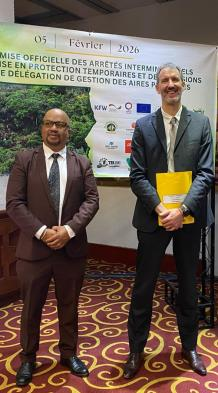


Plan_stratégique_Impact_page_48_image_1
category: an infographic
bbox: [474.75, 235.44998168945312, 553.5, 377.16998291015625]
deplot_valid: None


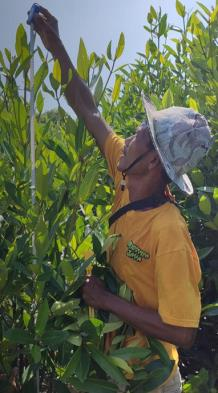


Plan_stratégique_Impact_page_48_image_4
category: a map
bbox: [39.0, 390.6709899902344, 121.5, 470.1549987792969]
deplot_valid: None


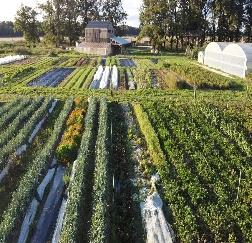


Plan_stratégique_Impact_page_48_image_2
category: a chart or graph showing numerical data
bbox: [474.75, 390.6709899902344, 553.5, 470.1549987792969]
deplot_valid: None


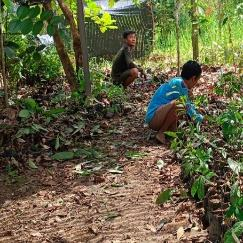

In [80]:
from IPython.display import display
from PIL import Image

page_number = 48

for element in pages_document[page_number - 1]["elements"]:

    if element["type"] != "image":
        continue

    print("\n" + "=" * 80)
    print(element["asset_id"])
    print("category:", element.get("image_category"))
    print("bbox:", element["bbox"])
    print("deplot_valid:", element.get("deplot_valid"))

    display(
        Image.open(element["storage_path"])
    )

In [81]:
candidates = []

for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        if not element.get("is_chart", False):
            continue

        candidates.append({
            "page": page_data["page"],
            "asset_id": element["asset_id"],
            "category": element["image_category"],
            "score": element["classification_score"],
            "deplot_valid": element.get("deplot_valid")
        })


candidates = sorted(
    candidates,
    key=lambda item: item["score"],
    reverse=True
)


for candidate in candidates:

    print(
        f"Page {candidate['page']}"
        f" | score: {candidate['score']:.3f}"
        f" | category: {candidate['category']}"
        f" | deplot_valid: {candidate['deplot_valid']}"
        f" | {candidate['asset_id']}"
    )

Page 15 | score: 0.944 | category: an infographic | deplot_valid: False | Plan_stratégique_Impact_page_15_image_1
Page 66 | score: 0.941 | category: an infographic | deplot_valid: False | Plan_stratégique_Impact_page_66_image_1
Page 14 | score: 0.903 | category: a chart or graph showing numerical data | deplot_valid: True | Plan_stratégique_Impact_page_14_image_1
Page 5 | score: 0.889 | category: an infographic | deplot_valid: True | Plan_stratégique_Impact_page_5_image_1
Page 63 | score: 0.889 | category: an infographic | deplot_valid: True | Plan_stratégique_Impact_page_63_image_1
Page 49 | score: 0.884 | category: an infographic | deplot_valid: True | Plan_stratégique_Impact_page_49_image_2
Page 40 | score: 0.793 | category: an infographic | deplot_valid: False | Plan_stratégique_Impact_page_40_image_1
Page 5 | score: 0.788 | category: an infographic | deplot_valid: False | Plan_stratégique_Impact_page_5_image_2
Page 14 | score: 0.752 | category: a chart or graph showing numerical d


Page: 14
asset_id: Plan_stratégique_Impact_page_14_image_3
category: a chart or graph showing numerical data
score: 0.602
deplot_valid: True


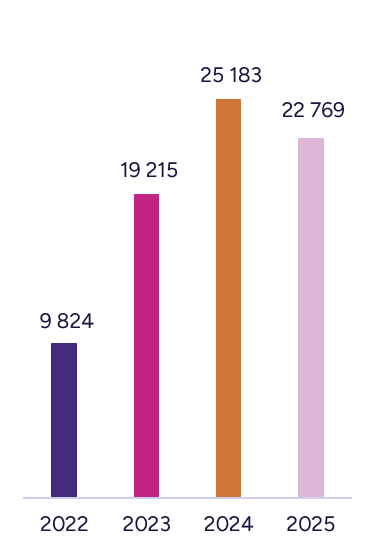


Page: 37
asset_id: Plan_stratégique_Impact_page_37_image_1
category: an infographic
score: 0.638
deplot_valid: False


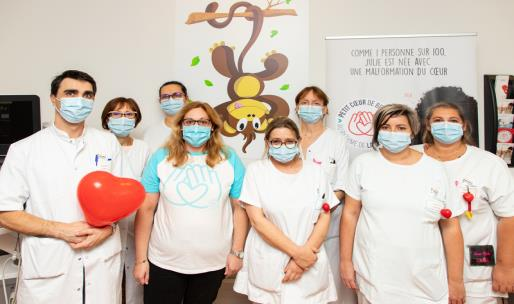


Page: 37
asset_id: Plan_stratégique_Impact_page_37_image_1
category: an infographic
score: 0.638
deplot_valid: False


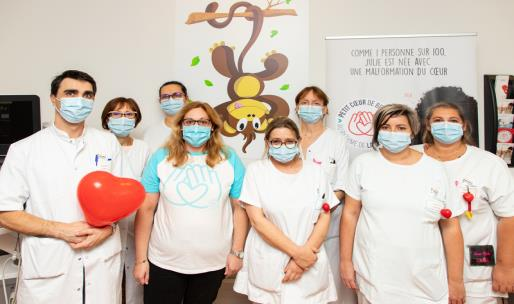


Page: 45
asset_id: Plan_stratégique_Impact_page_45_image_7
category: an infographic
score: 0.587
deplot_valid: True


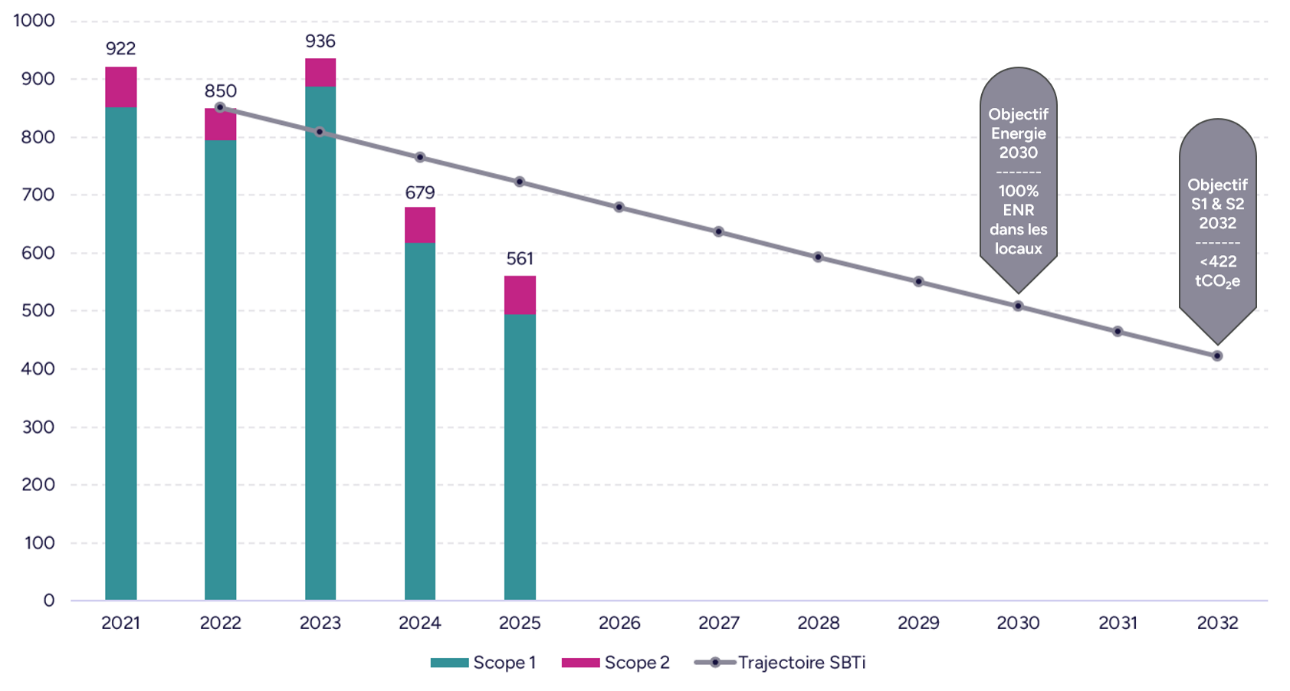


Page: 45
asset_id: Plan_stratégique_Impact_page_45_image_8
category: a chart or graph showing numerical data
score: 0.587
deplot_valid: True


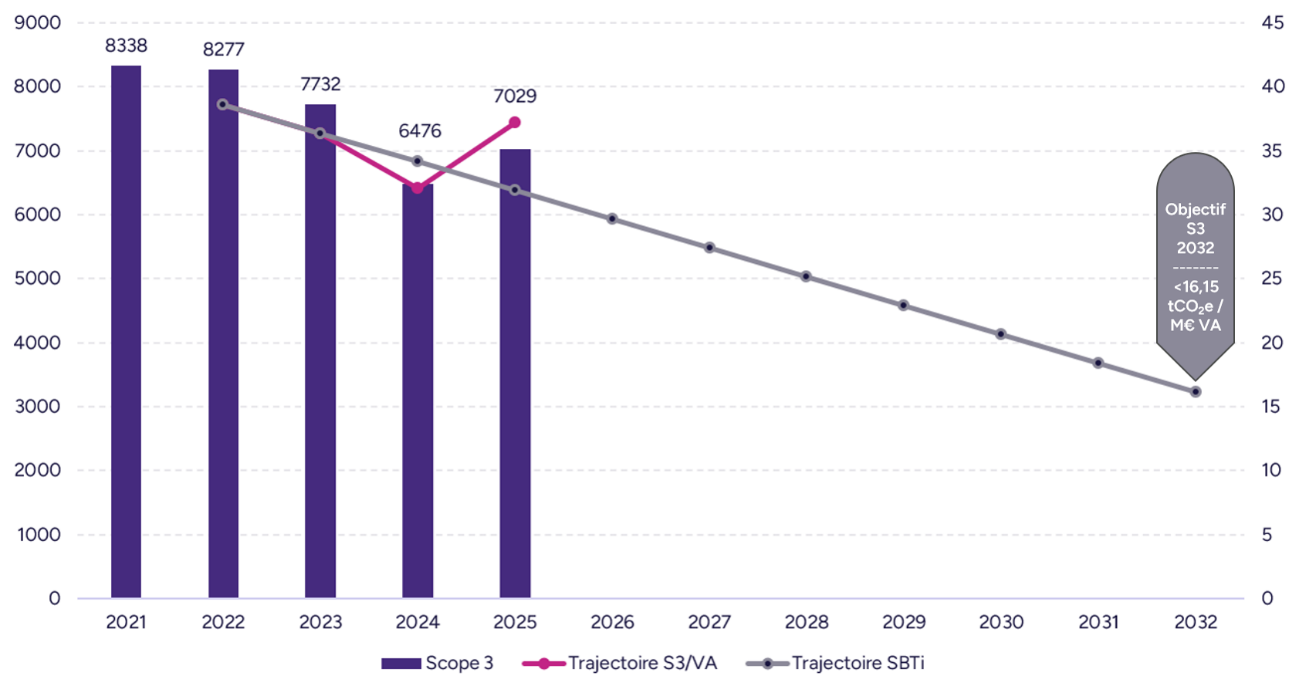

In [82]:
from IPython.display import display
from PIL import Image

for page_data in pages_document:
    for element in page_data["elements"]:

        if element["type"] != "image":
            continue

        if not element.get("is_chart", False):
            continue

        score = element["classification_score"]

        if score > 0.65:
            continue

        print("\n" + "=" * 80)

        print("Page:", page_data["page"])
        print("asset_id:", element["asset_id"])
        print("category:", element["image_category"])
        print("score:", round(score, 3))
        print("deplot_valid:", element.get("deplot_valid"))

        display(
            Image.open(element["storage_path"])
        )

# Embedding

In [83]:
texts_to_embed = [chunk["page_content"]for chunk in chunks]

In [84]:
print("Number of texts to embed :", len(texts_to_embed))

for text_index, text in enumerate(texts_to_embed):
    print("Text", text_index, "| Length :", len(text))

Number of texts to embed : 83
Text 0 | Length : 114
Text 1 | Length : 725
Text 2 | Length : 1911
Text 3 | Length : 2004
Text 4 | Length : 1176
Text 5 | Length : 1785
Text 6 | Length : 1965
Text 7 | Length : 1327
Text 8 | Length : 1671
Text 9 | Length : 1403
Text 10 | Length : 1701
Text 11 | Length : 196
Text 12 | Length : 2108
Text 13 | Length : 1976
Text 14 | Length : 346
Text 15 | Length : 2747
Text 16 | Length : 2778
Text 17 | Length : 1205
Text 18 | Length : 1123
Text 19 | Length : 370
Text 20 | Length : 2483
Text 21 | Length : 893
Text 22 | Length : 2051
Text 23 | Length : 2156
Text 24 | Length : 2235
Text 25 | Length : 1506
Text 26 | Length : 1269
Text 27 | Length : 845
Text 28 | Length : 1961
Text 29 | Length : 1748
Text 30 | Length : 1531
Text 31 | Length : 1421
Text 32 | Length : 184
Text 33 | Length : 2278
Text 34 | Length : 1490
Text 35 | Length : 1176
Text 36 | Length : 1684
Text 37 | Length : 1706
Text 38 | Length : 1162
Text 39 | Length : 864
Text 40 | Length : 188
Text 4

In [85]:
import os 
from dotenv import load_dotenv
load_dotenv(override=True)

os.environ['OPENAI_API_KEY']=os.getenv('OPENAI_API_KEY')

In [86]:
from langchain_openai import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-ada-002")

In [87]:
#embeddings = embedding_model.embed_documents(texts_to_embed)

# Chromadb ou Qdrant

In [88]:
#import chromadb

#chroma_client = chromadb.PersistentClient(path="chroma_db") # Les données seront conservées sur le disque dans le fichier chroma_db

In [89]:
import pywintypes

In [90]:
from qdrant_client import QdrantClient

qdrant_client = QdrantClient(path="qdrant_db")

In [91]:
from qdrant_client.models import Distance, VectorParams

test_collection = "pdf_pages_v2"

if qdrant_client.collection_exists(test_collection):
    qdrant_client.delete_collection(test_collection)

qdrant_client.create_collection(
    collection_name=test_collection,
    vectors_config=VectorParams(
        size=1536,
        distance=Distance.COSINE
    )
)

True

In [92]:
from langchain_qdrant import QdrantVectorStore

vector_store = QdrantVectorStore(
    client=qdrant_client,
    collection_name="pdf_pages_v2",
    embedding=embedding_model
)

In [93]:
# Création de la collection (table)

#collection = chroma_client.get_or_create_collection(name="pdf_pages")

In [94]:
# Identifiants qui seront utilisés dans Chroma

#chunk_ids = [chunk["chunk_id"] for chunk in chunks]

In [95]:
# Contenus Markdown associés aux identifiants

#chunk_documents = [chunk["page_content"] for chunk in chunks]

Nous avons 3 listes alignées:

- chunk_ids
- chunk_documents
- embeddings

Exemple pour la page 1:

- chunk_ids[0]
- chunk_documents[0]
- embeddings[0]

In [96]:
# Enregistrement des identifiants, contenus Markdown et embeddings dans Chroma

#collection.upsert(ids=chunk_ids, documents=chunk_documents, embeddings=embeddings)

In [97]:
#print("Number of records in Chroma :",collection.count())

In [98]:
#from langchain_chroma import Chroma

#vector_store = Chroma(client=chroma_client, collection_name="pdf_pages", embedding_function=embedding_model)

In [99]:
from langchain_core.documents import Document

documents = [Document(page_content=chunk["page_content"],metadata=chunk["metadata"]) for chunk in chunks]

In [100]:
vector_store.add_documents(
    documents=documents
)

['71aba1b1e1594a0eb8cabe2ff5357901',
 'dc93efec44ea4319a1fcdf0a88615e99',
 '7760f0cb11ff4023b6da69a524dc92af',
 'ce525a8f6d2b43c593aeab871b75c51b',
 '94471642f3524f949ced77229f6e614d',
 'ad2376faec90418c8aa9103f5b1b2f59',
 '402dde41f4a642df8757ad63b6fd0943',
 '6696d071f63e47439360066577275988',
 '9abbb982477d424eaf01125a5b2d0291',
 '7521a074d2f545e4b1af053185925b0e',
 '9f914f21dd244a84955fa380b67ed51b',
 '394067a35de147b58dd25e14b8392bb5',
 '652404e4deea460f94ab9bbe0977bf14',
 'cdc09198c8d543738d9fd4ba826e7bc0',
 '7e787d9fda24413faab3041aea0be6ea',
 'ce535f7a6b884b1aa5f3f0ce3874a341',
 '4965a9369da248a39e0dfdd225d8cda4',
 'e7749d2e68e84ac392d71917be915c1c',
 '01a27b5aa429414fb498eb5313b1bdd5',
 'e0daf5ac1a644de8a96f2fb87354ebb5',
 '9782fecc66bf4f17abd87650957fc01c',
 '38d75946964e4ee9bf9f00d8f4858b11',
 'c8aa050dc03e47429ebeaf663d2e5f9d',
 '8c9f1a7dbb0c4c8ea23dce010fc788d6',
 '6da0c85dc38543729594e27a80ddfa9c',
 'e029a8865d9f463d8cec836f3de72c4e',
 'b2bd18e80dc64f72b9aa806622033ae2',
 

In [101]:
results = vector_store.similarity_search(
    "Quels sont les projets de philanthropie climatique ?",
    k=5
)

In [102]:
for result in results:

    print(
        "Page:",
        result.metadata.get("page")
    )

    print(
        result.page_content[:500]
    )

    print("=" * 80)

Page: 48
ESSENTIEL

MODÈLE D'AFFAIRES

SOCIAL

SOCIÉTAL

ENVIRONNEMENT

ÉTHIQUE

NUMÉRIQUE

ACHATS

ANNEXES

Engagements

SBTiSBTi

Plan de transition

Couverture par filiale

Actions et indicateurs

Bilan carbone

Philanthropie

Little Big Map

Nos projets de philanthropie climatique

La contribution carbone ne peut en aucun cas se substituer à des actions concrètes de réduction. Elle intervient de manière volontaire, en complément de la réduction,
afin d’agir uniquement sur nos émissions incompressible
Page: 48
ESSENTIEL
ESSENTIEL

MODÈLE D'AFFAIRES
MODÈLE D'AFFAIRES

SOCIAL
SOCIAL

SOCIÉTAL
SOCIÉTAL

ENVIRONNEMENT
ENVIRONNEMENT

ÉTHIQUE
ÉTHIQUE

NUMÉRIQUE
NUMÉRIQUE

ACHATS
ACHATS

ANNEXES
ANNEXES

Engagements
Engagements

SBTiSBTi

Plan de transition
Plan de transition

Couverture par filiale
Couverture par filiale

Actions et indicateurs
Actions et indicateurs

Bilan carbone
Bilan carbone

Philanthropie
Philanthropie

Little Big Map
Little Big Map

Nos projets de philanthropie clim

# Retriever

In [104]:
retriever = vector_store.as_retriever(search_kwargs={"k": 2})

In [107]:
question = "Quels sont les projets de philanthropie climatique"

retrieved_documents = retriever.invoke(
    question
)

print(
    "Number of retrieved documents :",
    len(retrieved_documents)
)

for rank, document in enumerate(
    retrieved_documents,
    start=1
):

    print("\n" + "=" * 80)
    print("Rank :", rank)

    print(
        "Chunk ID :",
        document.metadata.get("chunk_id")
    )

    print(
        "Page :",
        document.metadata.get("page")
    )

    print(
        "File :",
        document.metadata.get("file_name")
    )

    print("\nContent :")
    print(document.page_content)

Number of retrieved documents : 2

Rank : 1
Chunk ID : Plan_stratégique_Impact_page_48
Page : 48
File : Plan_stratégique_Impact.pdf

Content :
ESSENTIEL

MODÈLE D'AFFAIRES

SOCIAL

SOCIÉTAL

ENVIRONNEMENT

ÉTHIQUE

NUMÉRIQUE

ACHATS

ANNEXES

Engagements

SBTiSBTi

Plan de transition

Couverture par filiale

Actions et indicateurs

Bilan carbone

Philanthropie

Little Big Map

Nos projets de philanthropie climatique

La contribution carbone ne peut en aucun cas se substituer à des actions concrètes de réduction. Elle intervient de manière volontaire, en complément de la réduction,
afin d’agir uniquement sur nos émissions incompressibles et historiques. Aucune «neutralité carbone » ne peut être revendiquée.

Depuis 2021, Davidson contribue au développement de projets de restaurations d’écosystèmes et d’agroforesterie, à hauteur d’au moins 2‰ de son chiffre d’affaires
annuel. Par la séquestration de carbone qu’ils engendrent, ils nous permettent, en complément de nos efforts de réduction

# LLM

In [108]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-5-mini")

In [109]:
# Index des chunks complets
chunks_by_id = {
    chunk["chunk_id"]: chunk
    for chunk in chunks
}

In [ ]:
# Préparation source
context_parts = []

for document in retrieved_documents:

    source_chunk = chunks_by_id[
        document.id
    ]

    page_number = source_chunk["metadata"]["page"]
    file_name = source_chunk["metadata"]["file_name"]

    context_part = (
        f"[Source: {file_name}, page {page_number}]\n"
        f"{document.page_content}"
    )

    context_parts.append(context_part)

In [ ]:
context = "\n\n---\n\n".join(
    context_parts
)

In [ ]:
print(context)

[Source: test.pdf, page 2]
![logo](asset://test_page_2_image_0)

![chart](asset://test_page_2_image_1)

### Graphique 5.2.2 Élèves possèdant un télephone intelligent à l'école des Bois-Francs, selon le genre, 2012 à 2019

| Nombre d'élèves | Garçons | Filles |
| --- | --- | --- |
| 2012 | 110 | 85 |
| 2013 | 185 | 175 |
| 2014 | 241 | 224 |
| 2015 | 286 | 296 |
| 2016 | 305 | 280 |
| 2017 | 309 | 315 |
| 2018 | 314 | 305 |
| 2019 | 314 | 320 |

---

[Source: test.pdf, page 1]
TEST

Qu’est-ce que la génération à enrichissement contextuel ?

La génération à enrichissement contextuel (RAG) est le processus consistant à optimiser le résultat d’un grand modèle de

langage. Elle fait donc appel à une base de connaissances fiable externe aux sources de données utilisées pour l’entraîner

avant de générer une réponse. Les grands modèles de langage (LLM) sont entraînés avec d’importants volumes de données et

utilisent des milliards de paramètres pour générer des résultats originaux pour des tâ

In [110]:
from langchain_core.prompts import ChatPromptTemplate

prompt_template = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            """
Tu es un assistant qui répond à partir de documents fournis.

Utilise uniquement les informations présentes dans les sources.
Si les sources ne permettent pas de répondre, indique que l'information n'a pas été trouvée.
Indique le nom du fichier et le numéro de page utilisés.
Réponds en français de manière claire et concise.
""".strip()
        ),
        (
            "human",
            """
Question :
{question}

Sources :
{context}
""".strip()
        )
    ]
)

In [111]:
chain = prompt_template | llm

In [114]:
def rag_answer(question: str):

    # Recherche des pages pertinentes
    retrieved_documents = retriever.invoke(
        question
    )

    # Construction du contexte
    context_parts = []

    for document in retrieved_documents:

        file_name = document.metadata[
            "file_name"
        ]

        page_number = document.metadata[
            "page"
        ]

        context_part = (
            f"[Source: {file_name}, page {page_number}]\n"
            f"{document.page_content}"
        )

        context_parts.append(
            context_part
        )

    context = "\n\n---\n\n".join(
        context_parts
    )

    # Génération
    response = chain.invoke(
        {
            "question": question,
            "context": context
        }
    )

    return response.content

In [117]:
answer = rag_answer("Quels sont les projets de philanthropie climatique?")
print(answer)

Les projets de philanthropie climatique indiqués sont (Plan_stratégique_Impact.pdf, p.48) :

- Projet Tapia — De 2021 à 2023 : préservation de forêts naturelles, protection d'espèces endémiques (tapia, ver à soie sauvage « Landibe ») et résilience économique des communautés locales.  
- Projet MERCI — De 2022 à 2024 : préservation des mangroves pour protéger populations, cultures et espèces menacées.  
- Agroécologie dans des fermes françaises — Annuel : soutien à des projets agricoles visant à nourrir la population avec des aliments sains, préserver le capital naturel et garantir une activité viable et résiliente pour les agriculteurs.  
- Projet Way Kambas — Depuis 2024 : restauration des écosystèmes du parc national de Way Kambas et renforcement de la résilience des communautés environnantes.

Source : Plan_stratégique_Impact.pdf, page 48.
